# Load packages

Read in all necessary packages:

In [ ]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scanpy as sc
import numpy as np
import decoupler as dc


In [2]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [3]:
import decoupler as dc

In [4]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

## load adata file and define groups for differential expression

In [5]:
adata = sc.read_h5ad('../../../tchic_local/fig6_build/legacy/data/20230704_adata_all.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_par

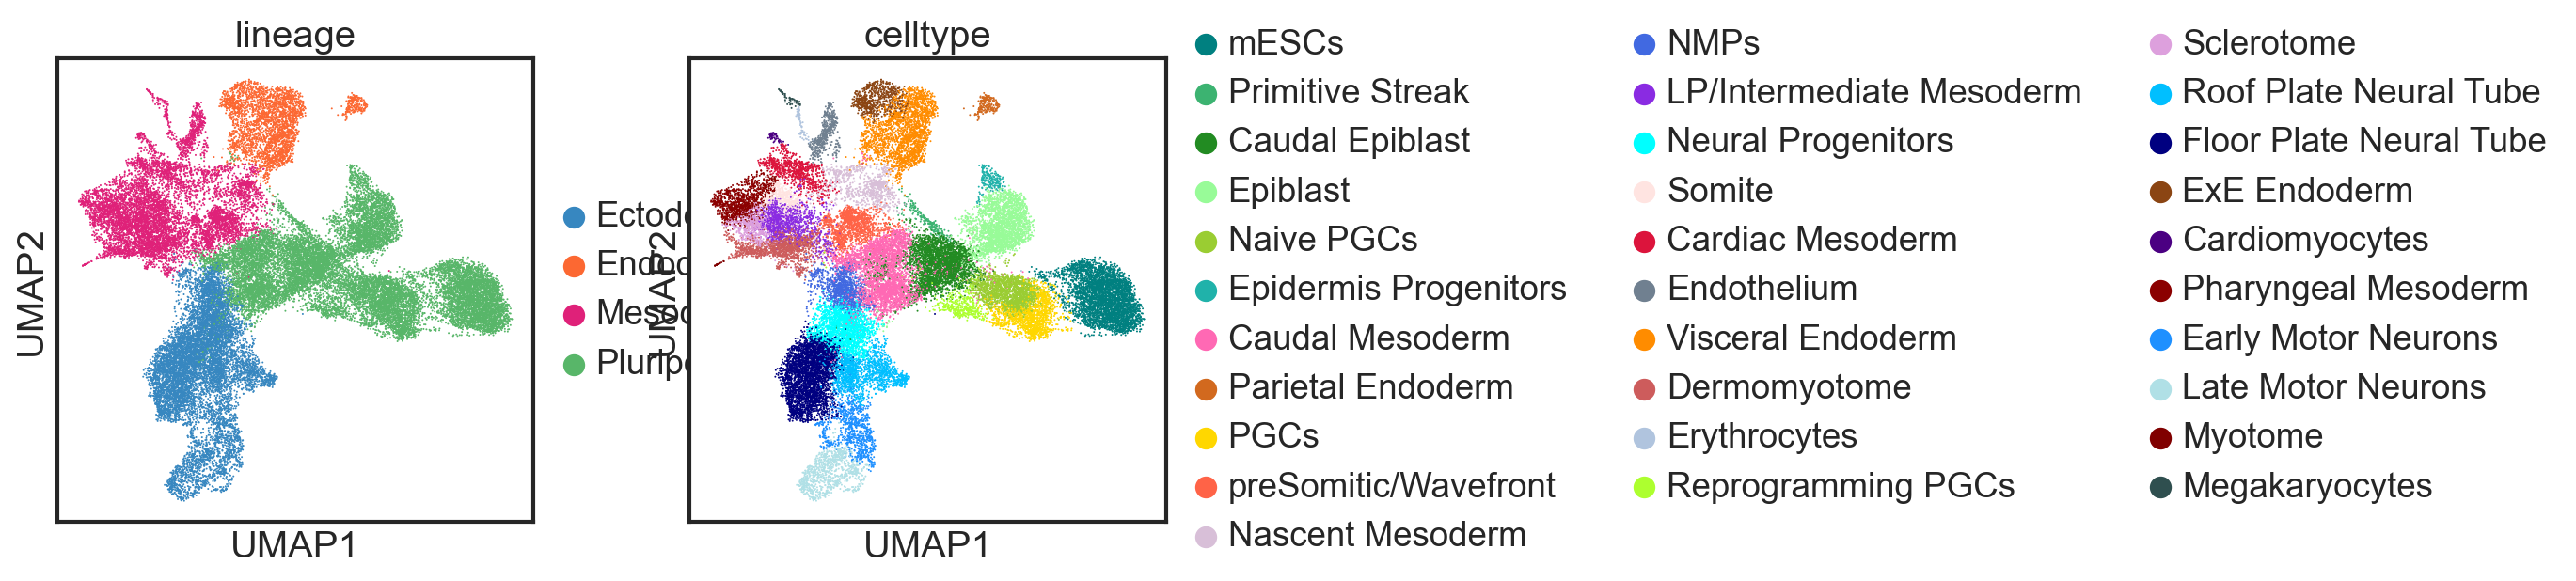

In [6]:
sc.pl.umap(adata, color = ['lineage', 'celltype'])

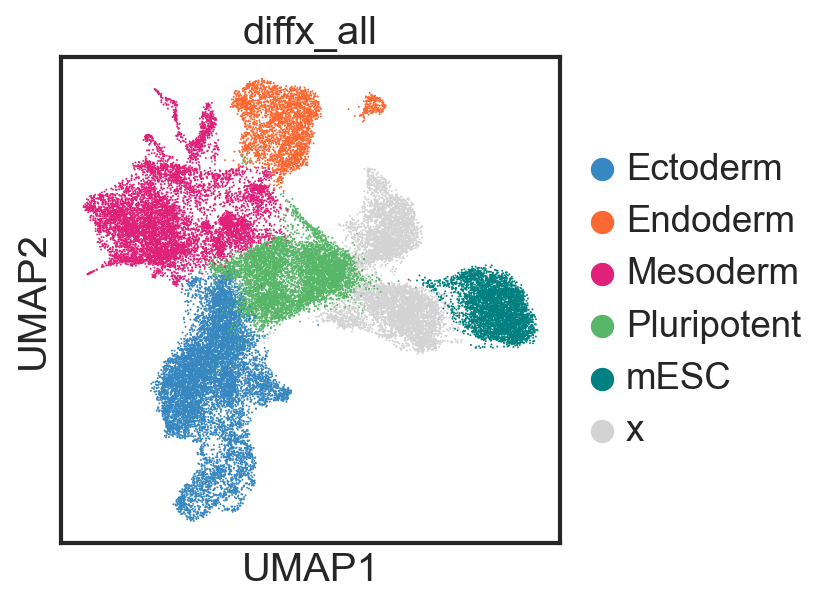

In [7]:
dict_ct = {'Mesoderm':'Mesoderm',
 'Ectoderm':'Ectoderm',
 'Endoderm':'Endoderm',
           'Pluripotent':'Pluripotent'}

adata.obs['diffx_all'] = (
    adata.obs["lineage"]
    .map(lambda x: dict_ct.get(x, x))
    .astype("category")
)

adata.obs['diffx_all'] = adata.obs['diffx_all'].astype(str)
adata.obs.loc[list(adata[adata.obs['celltype'] == 'mESCs'].obs.index), 'diffx_all'] = 'mESC'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'PGCs'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epidermis Progenitors'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epiblast'].obs.index), 'diffx_all'] = 'x'

cols = ['#3787c0', '#fc6832','#df2179', '#58b669','teal','lightgrey']
sc.pl.umap(adata, color = 'diffx_all', palette = cols )

## all comparisons

In [8]:
dict_ct = {'Mesoderm':'x','Ectoderm':'x','Endoderm':'x',
           'Pluripotent':'Pluripotent','x':'x','mESC':'mESC'}
adata.obs['diffx_ESC_p'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))


dict_ct = {'Mesoderm':'diff','Ectoderm':'diff','Endoderm':'diff',
           'Pluripotent':'Pluripotent','x':'x','mESC':'x'}
adata.obs['diffx_p_diff'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))

dict_ct = {'Mesoderm':'Mesoderm','Ectoderm':'Ectoderm','Endoderm':'Endoderm',
           'Pluripotent':'Pluripotent','x':'x','mESC':'x'}
adata.obs['diffx_diff_p'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))

adata.uns['diffx_ESC_p_colors'] = ['#58b669','teal','lightgrey']
adata.uns['diffx_p_diff_colors'] = ['#58b669','#df2179','lightgrey']
adata.uns['diffx_diff_p_colors'] = ['#3787c0', '#fc6832','#df2179', '#58b669','lightgrey']

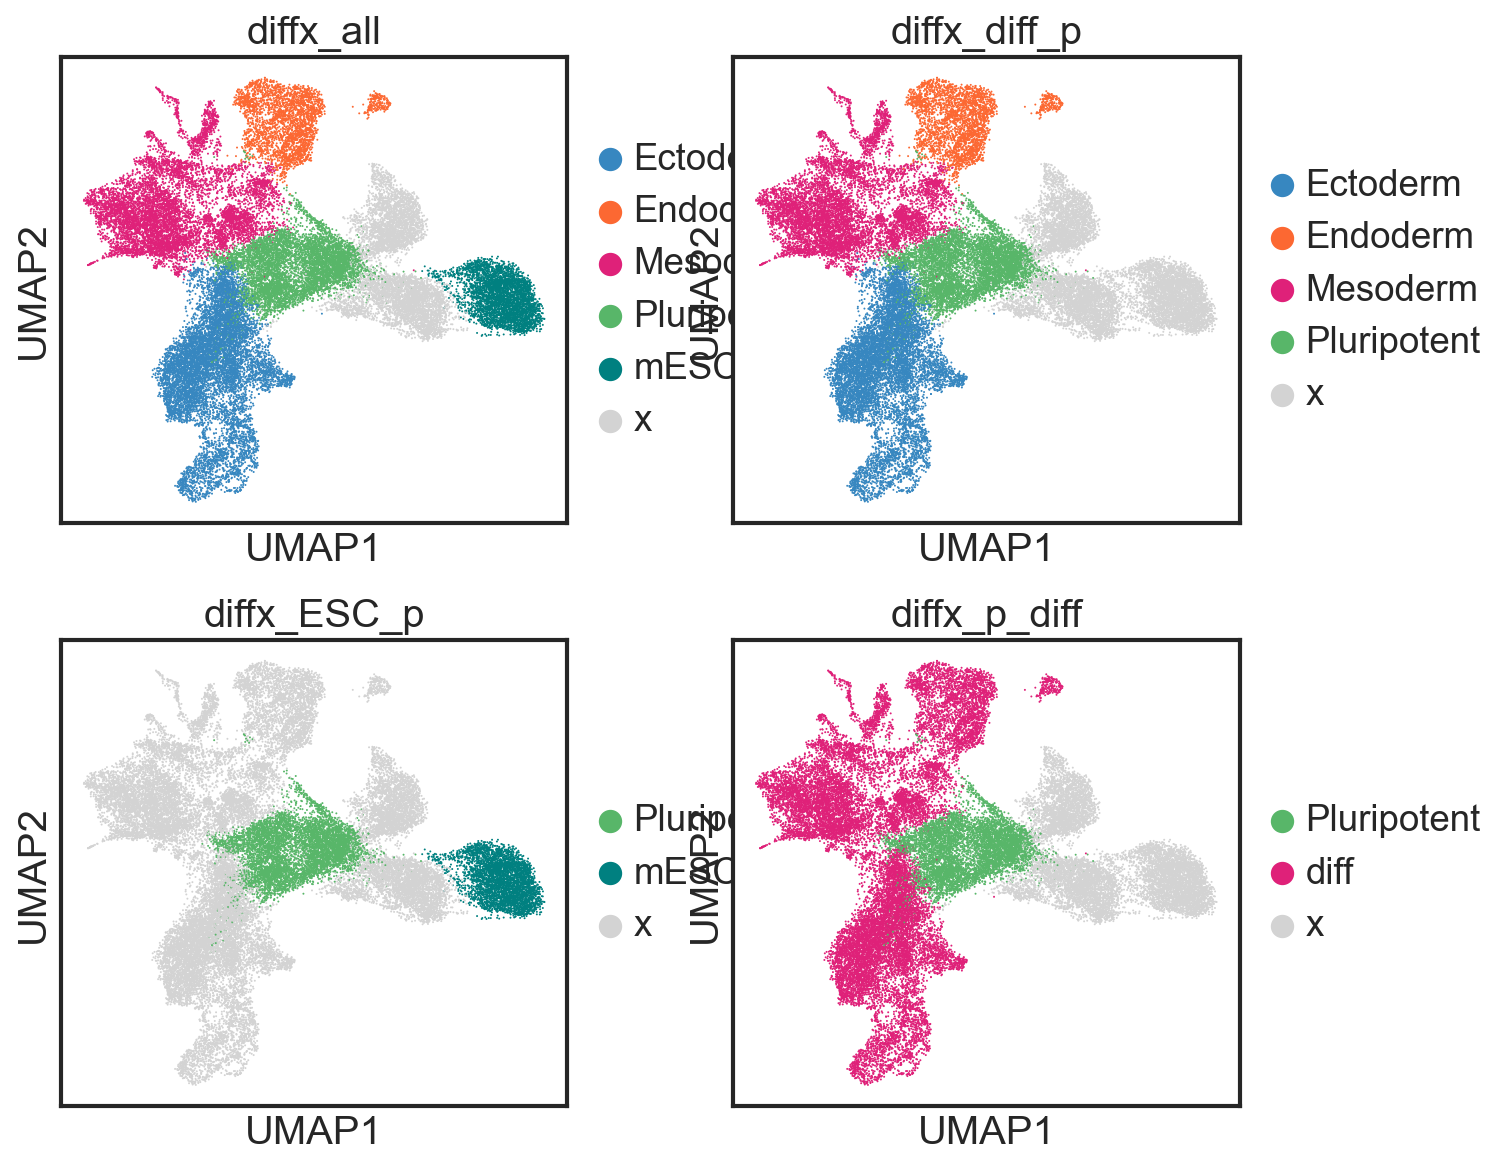

In [9]:
sc.pl.umap(adata, color = ['diffx_all','diffx_diff_p','diffx_ESC_p','diffx_p_diff'], ncols = 2)

In [10]:
sc.settings.verbosity = 2

# start decoupler
make pseudobulks, filter, run pydeseq

## Identify and isolate groups to compare
Add back raw counts before pseudobulking - first group cells into pseudobulks, then normalise and log-transform counts again

In [11]:
groups = 'diffx_p_diff'
reps = 'batch'

In [12]:
adata.X = adata.layers['matrix']

In [13]:
# only keep cells annotated in diffx
adata_f = adata[adata.obs[groups] != 'x']

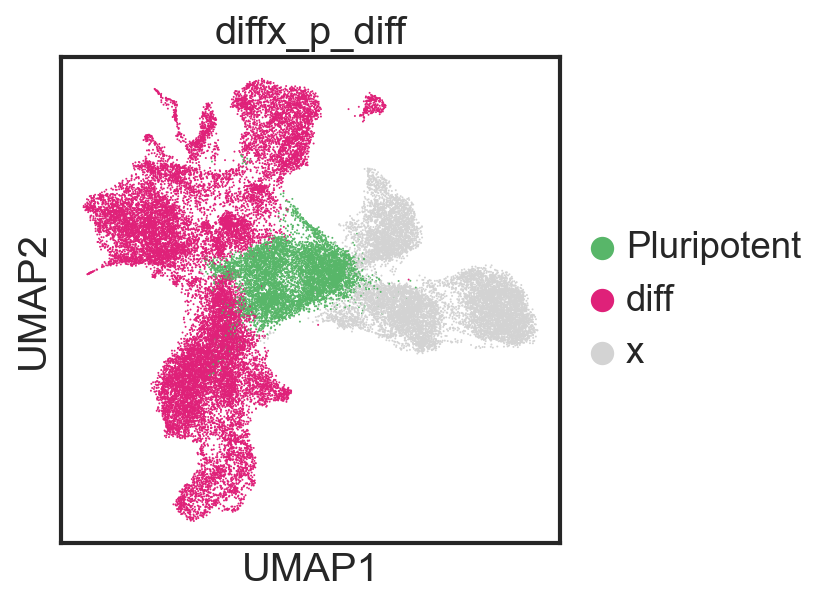

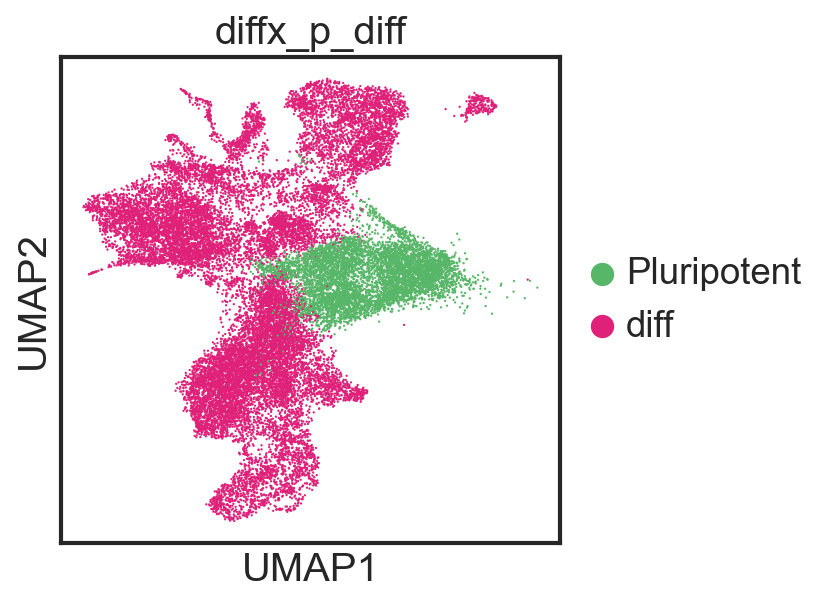

In [14]:
sc.pl.umap(adata, color = groups)
sc.pl.umap(adata_f, color = groups)

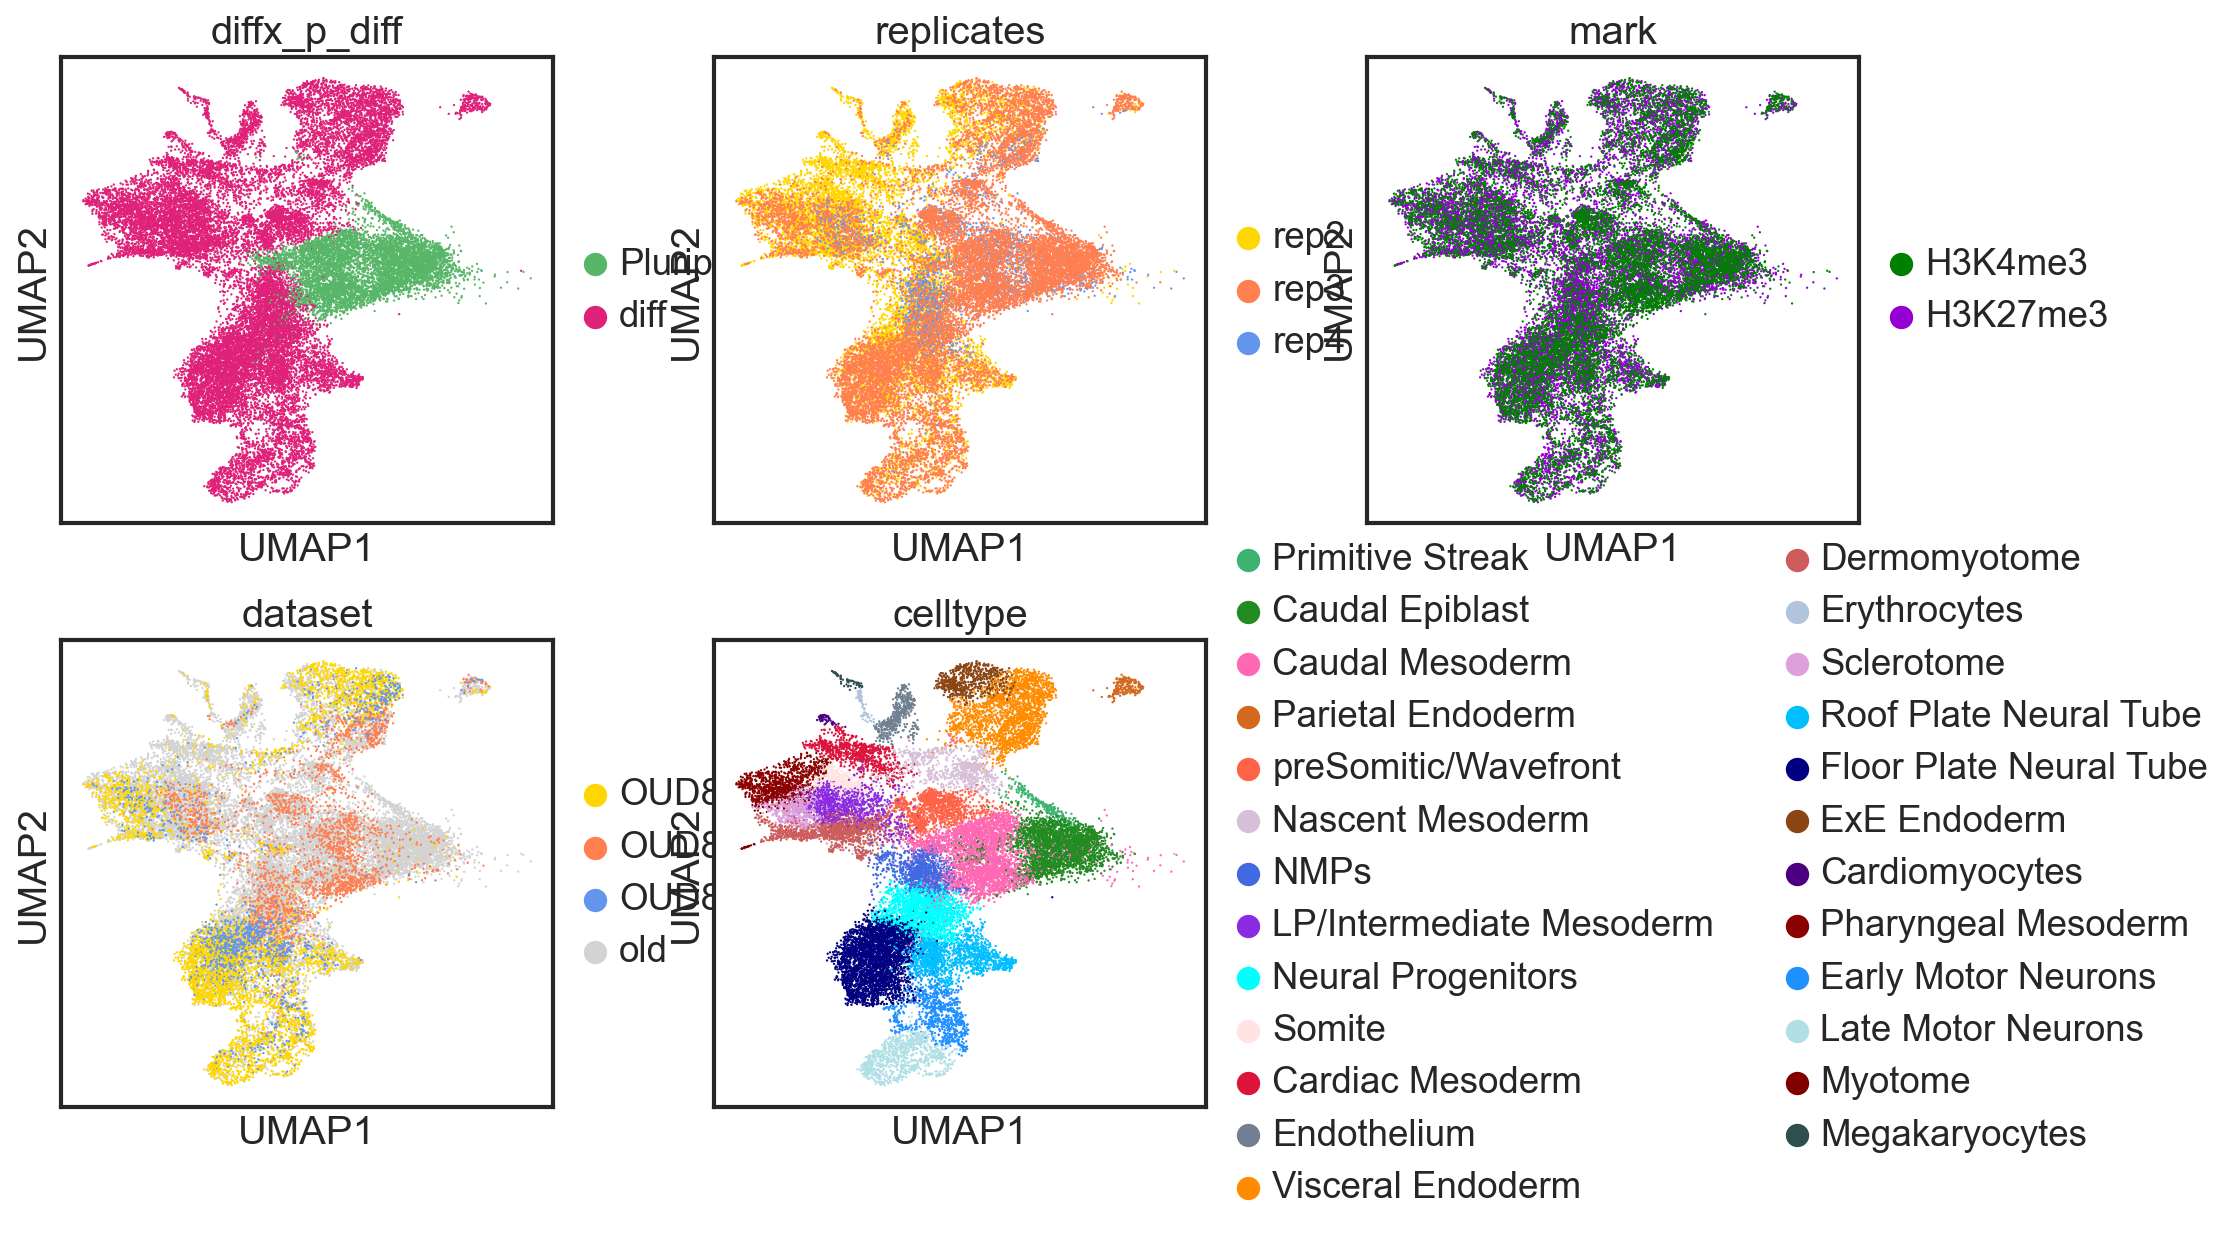

In [15]:
sc.pl.umap(adata_f, color = [groups,'replicates','mark','dataset','celltype'],ncols=3)

## define pseudobulks 

In [16]:
pd.DataFrame(adata_f.obs[[groups]].value_counts())


,count
diffx_p_diff,
diff,21198
Pluripotent,6629


/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_51510/3919780850.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot = adata_f.obs[adata.obs[reps].isin(list(adata_f.obs[reps].value_counts().head(25).index))]
/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_51510/3919780850.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot[reps] = plot[reps].astype(str)


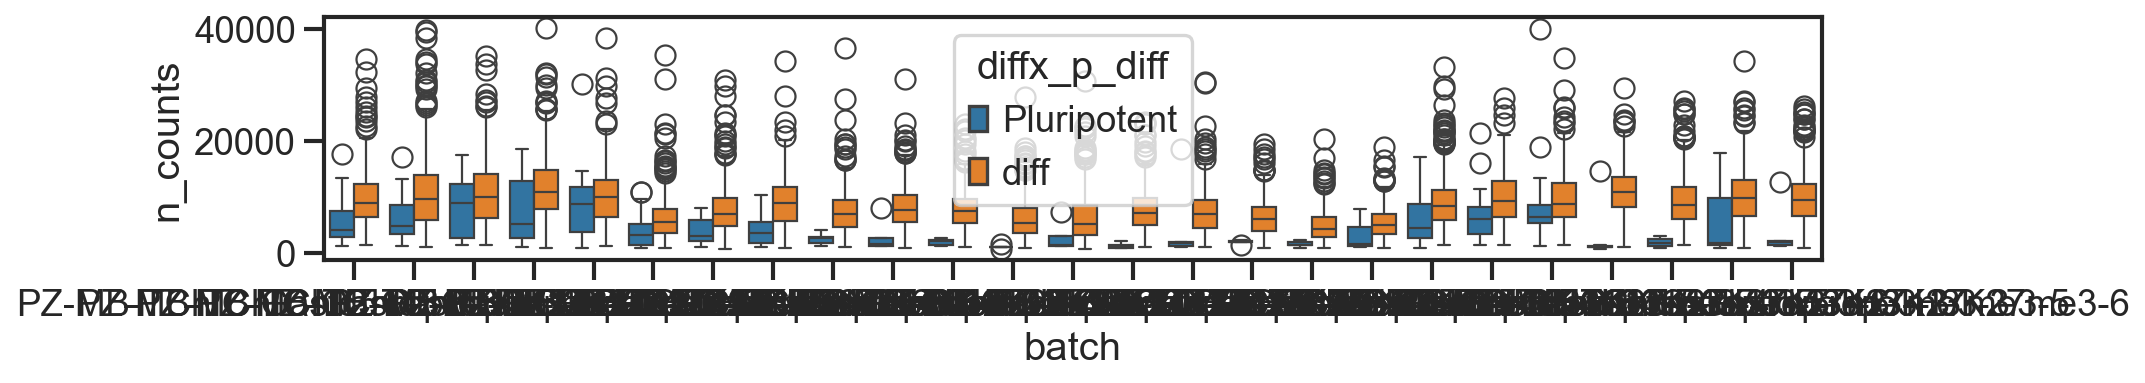

In [17]:
plot = adata_f.obs[adata.obs[reps].isin(list(adata_f.obs[reps].value_counts().head(25).index))]
plot[reps] = plot[reps].astype(str)

fig,ax = plt.subplots(figsize = (12,2))
sns.boxplot(data = plot
            ,ax=ax,
           x = reps,
           y = 'n_counts',
           hue = groups)
plt.show()

In [18]:
# Get pseudo-bulk profile
pdata = dc.get_pseudobulk(
    adata_f,
    groups_col= groups,
    sample_col= reps,
    mode='mean',
    min_cells=10,
    min_counts=0
)


/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/decoupler/plotting.py:980: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, title=grp)
/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/decoupler/plotting.py:980: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, title=grp)


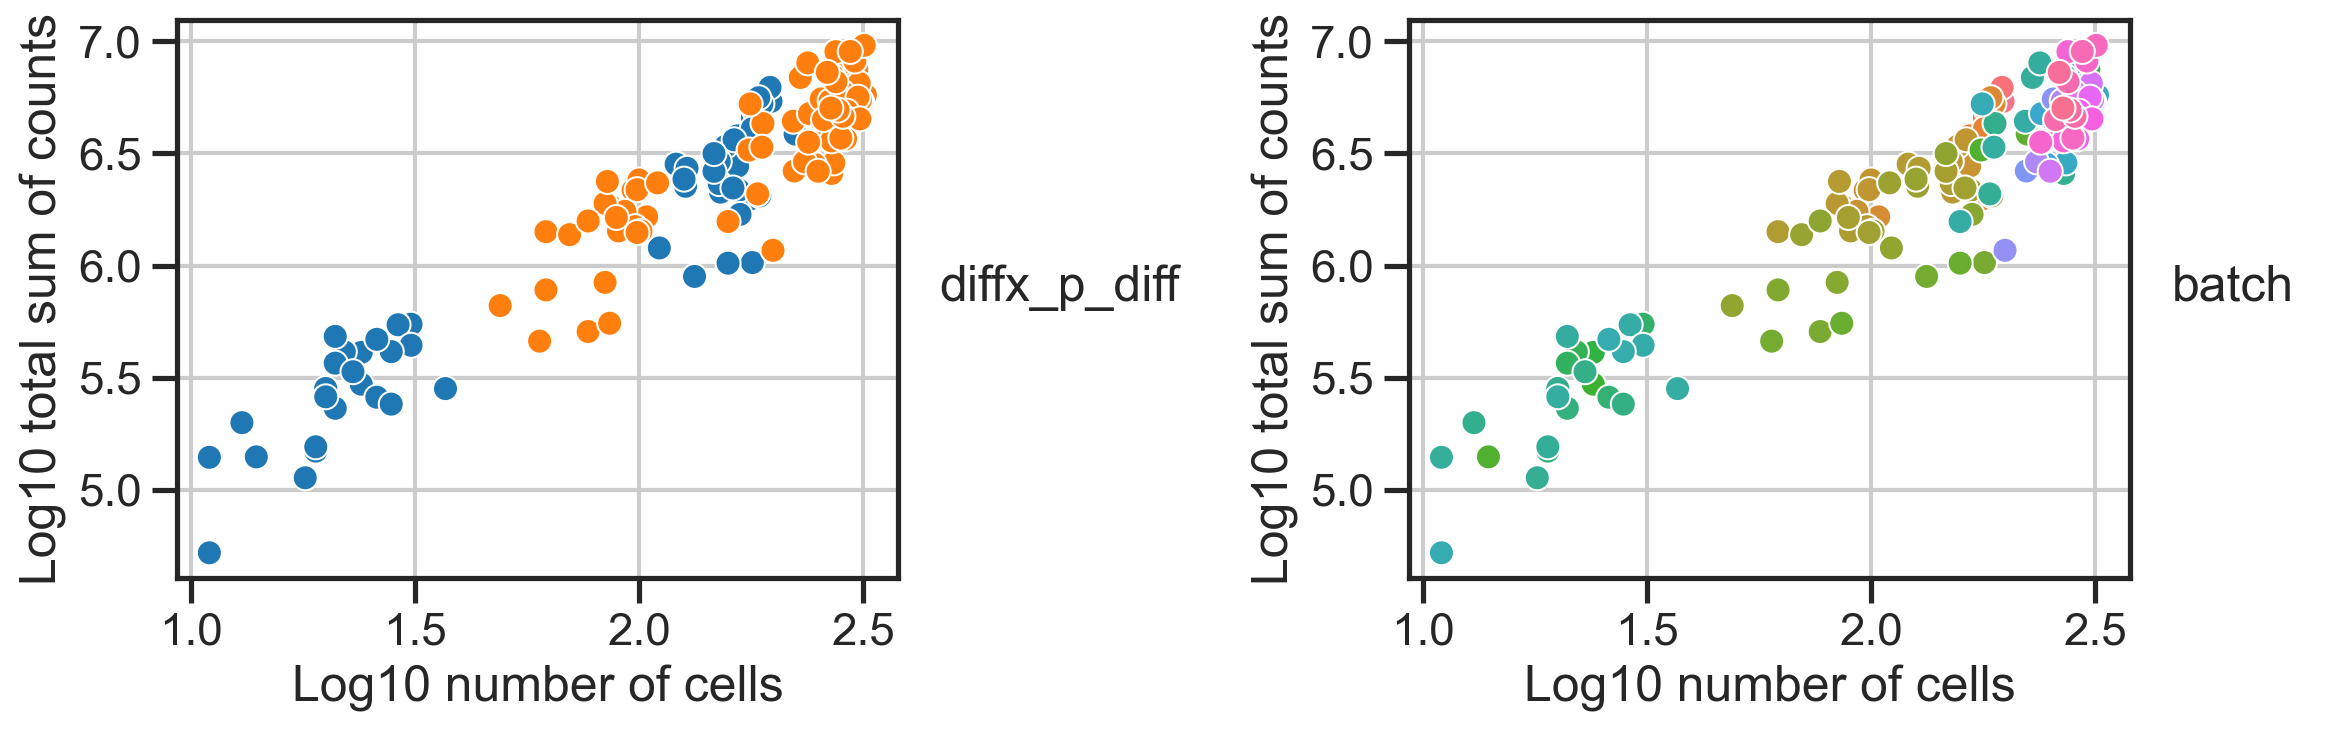

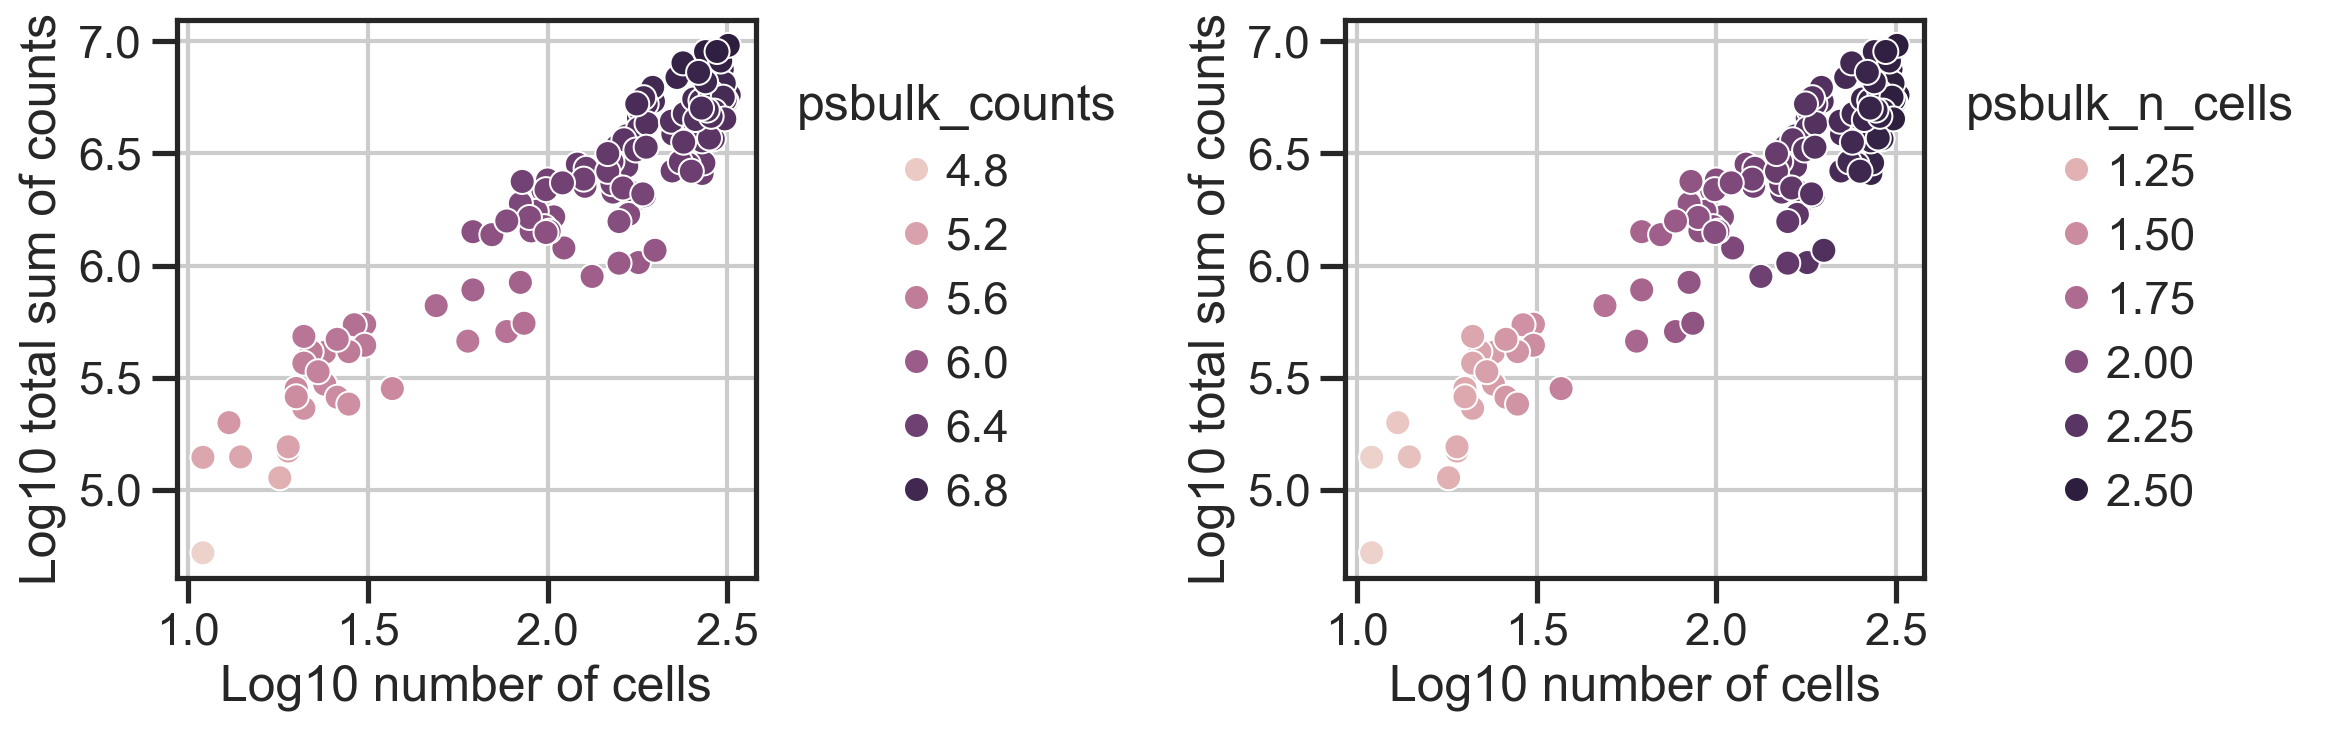

In [19]:
dc.plot_psbulk_samples(pdata, groupby=[groups, reps],figsize=(12, 4), legend = None)
plt.show()
dc.plot_psbulk_samples(pdata, groupby=['psbulk_counts','psbulk_n_cells'], figsize=(12, 4))
plt.show()


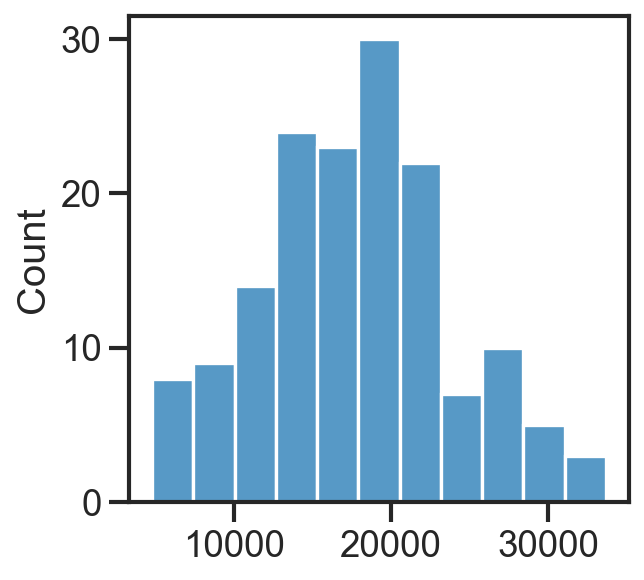

In [20]:
sns.histplot(pdata.obs['psbulk_counts']/pdata.obs['psbulk_n_cells'])
plt.show()

## filter pseudobulks

In [21]:
count_cutoff = 300000
cell_cutoff = 50

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_51510/618031605.py:5: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.stripplot(data = pdata.obs,


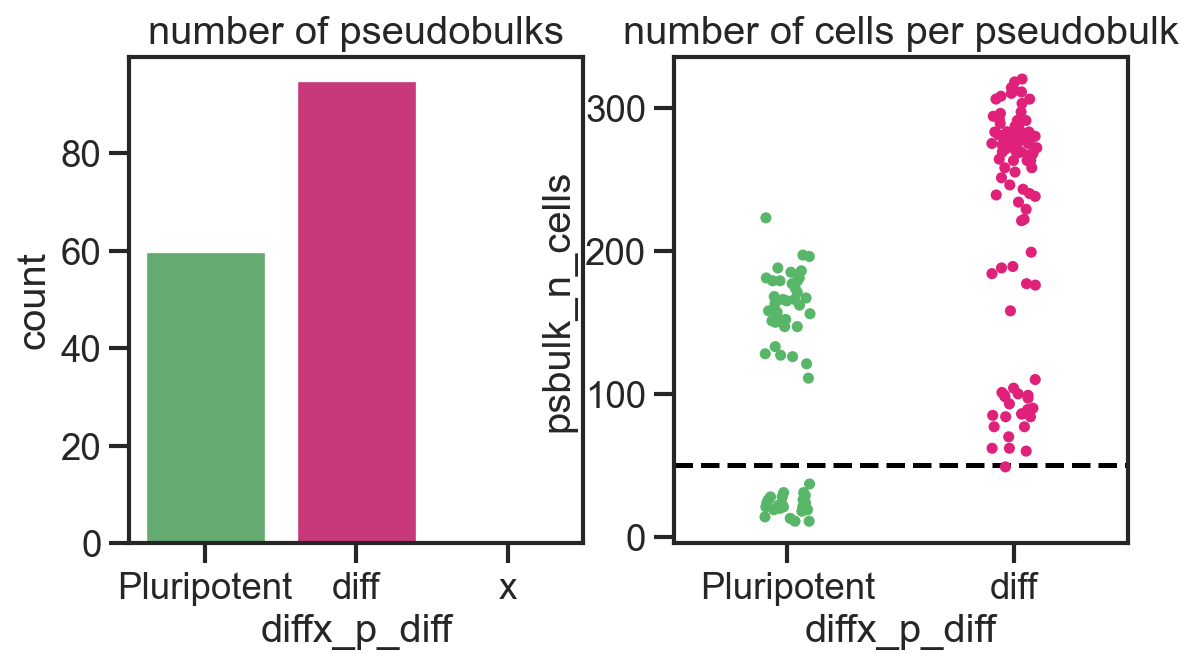

In [22]:
fig,ax = plt.subplots(1,2,figsize = (8,4))
sns.barplot(pdata.obs[groups].value_counts(),ax=ax[0],
            order= adata.obs[groups].cat.categories, palette = adata.uns[str(groups) + '_colors'])
ax[0].set_title('number of pseudobulks')
sns.stripplot(data = pdata.obs,
            x = groups,ax=ax[1],
            y = 'psbulk_n_cells', palette = adata.uns[str(groups) + '_colors'])
ax[1].axhline(cell_cutoff, c='black', linestyle='dashed')
ax[1].set_title('number of cells per pseudobulk')
plt.show()

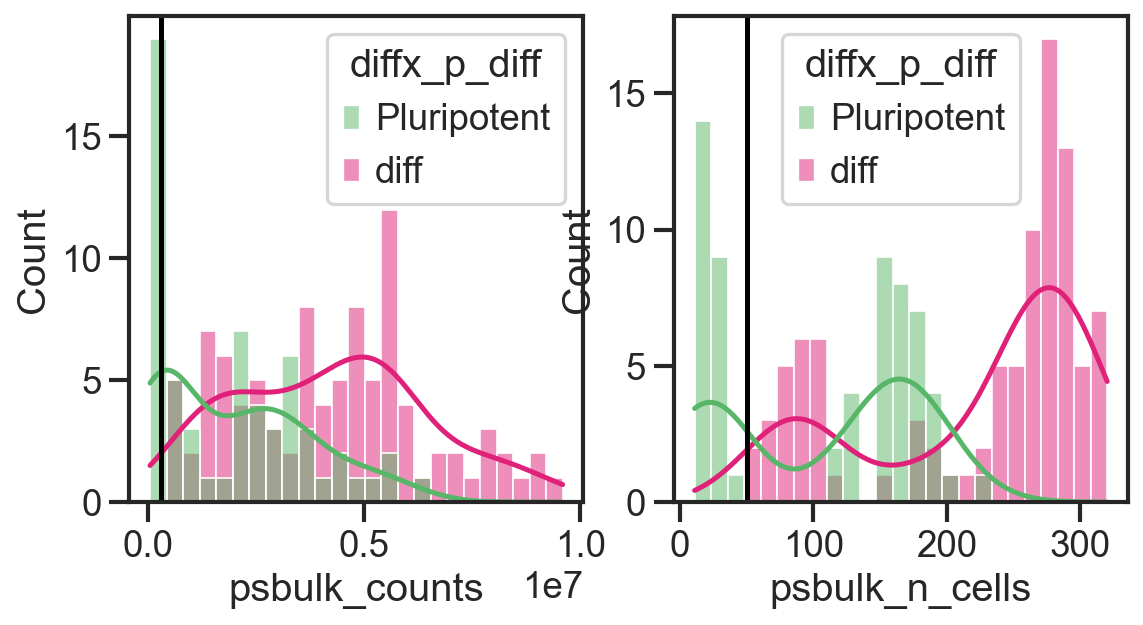

In [23]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax = ax.flatten()
sns.histplot(data = pdata.obs,
             x = 'psbulk_counts',ax=ax[0], bins = 25, hue = groups, kde = True,
             palette = adata.uns[str(groups) + '_colors'][0:2])
ax[0].axvline(count_cutoff, color = 'black')
sns.histplot(data = pdata.obs,
             x = 'psbulk_n_cells',ax=ax[1], bins = 25, hue = groups, kde = True,
             palette = adata.uns[str(groups) + '_colors'][0:2])
ax[1].axvline(cell_cutoff, color = 'black')
plt.show()

In [24]:
# Get pseudo-bulk profile
pdata = dc.get_pseudobulk(
    adata_f,
    groups_col=groups,
    sample_col=reps,
    mode='sum',
    min_cells=cell_cutoff,
    min_counts=count_cutoff
)

/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/decoupler/plotting.py:980: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, title=grp)
/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/decoupler/plotting.py:980: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, title=grp)


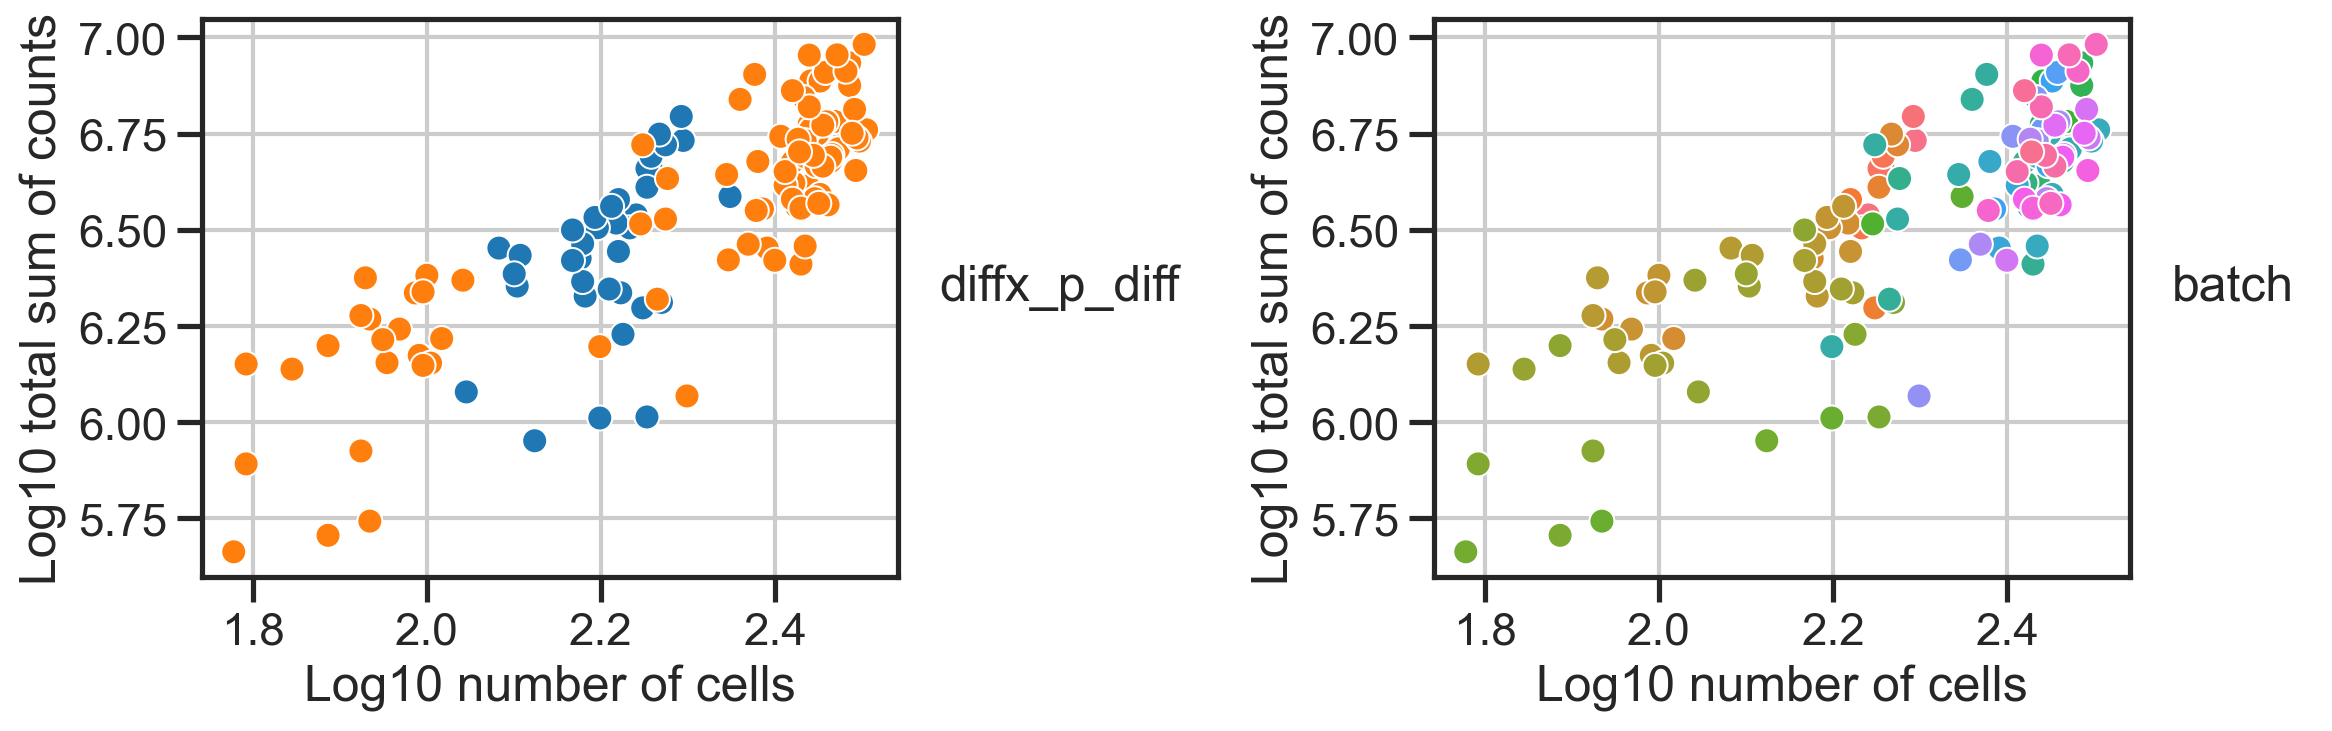

In [25]:
dc.plot_psbulk_samples(pdata, groupby=[groups,reps],figsize=(12, 4),legend = None)
plt.show()

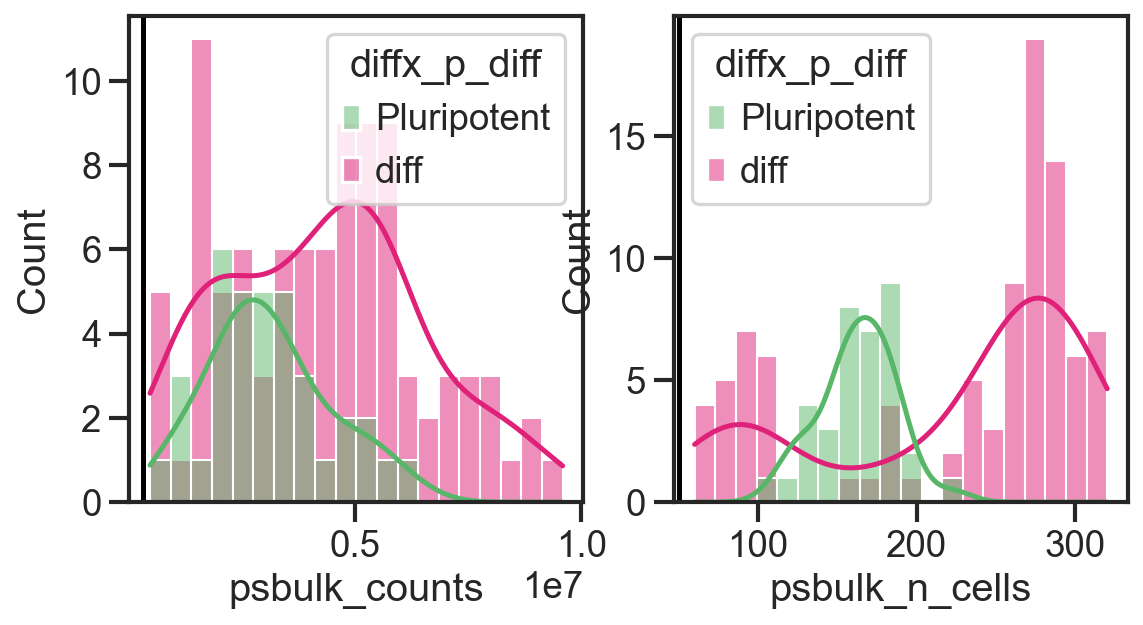

In [26]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax = ax.flatten()
sns.histplot(data = pdata.obs,
             x = 'psbulk_counts',ax=ax[0], bins = 20, hue = groups, kde = True, 
             palette = adata.uns[str(groups) + '_colors'][0:2])
ax[0].axvline(count_cutoff, color = 'black')
sns.histplot(data = pdata.obs,
             x = 'psbulk_n_cells',ax=ax[1], bins = 20, hue = groups, kde = True,
             palette = adata.uns[str(groups) + '_colors'][0:2])
ax[1].axvline(cell_cutoff, color = 'black')
plt.show()

## normalise and log-transform counts

In [27]:
# Store raw counts in layers
pdata.layers['counts'] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.swap_layer(pdata, 'counts', X_layer_key=None, inplace=True)


normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:00)


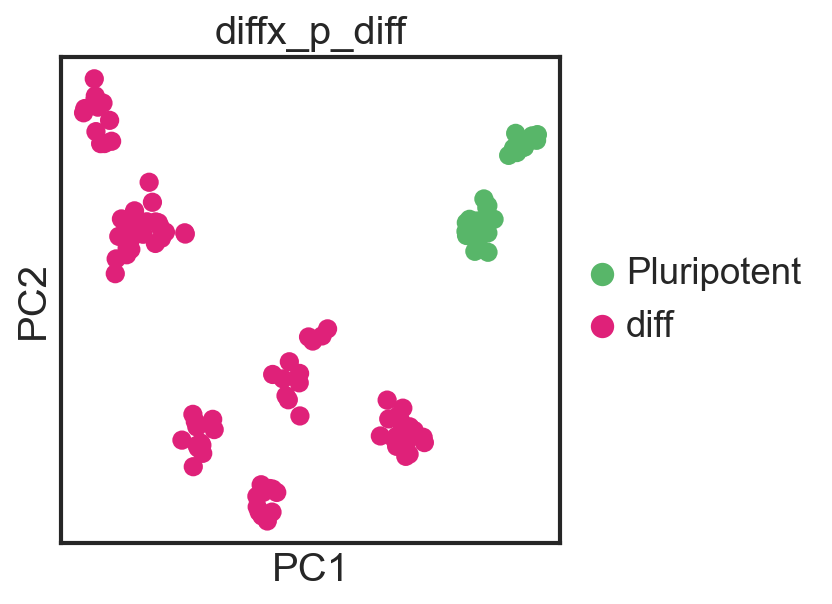

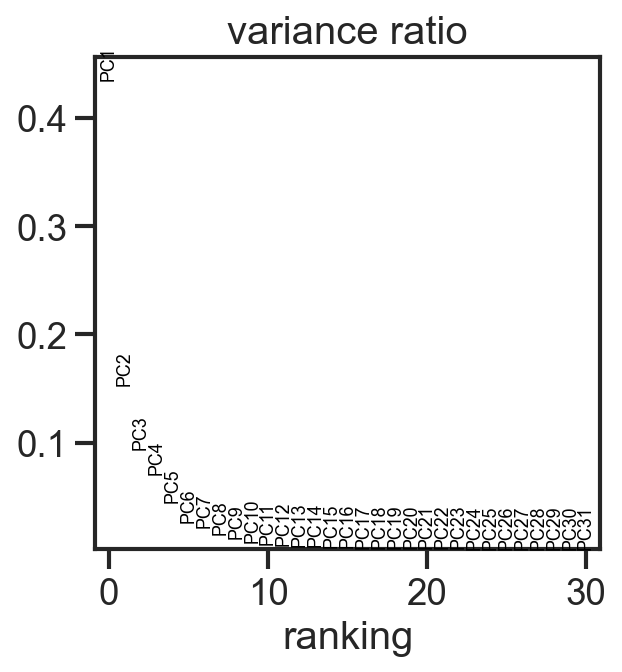

In [28]:
sc.pl.pca(pdata, color=[groups], ncols=3, size=300, palette = adata.uns[str(groups) + '_colors'][0:2])
sc.pl.pca_variance_ratio(pdata)



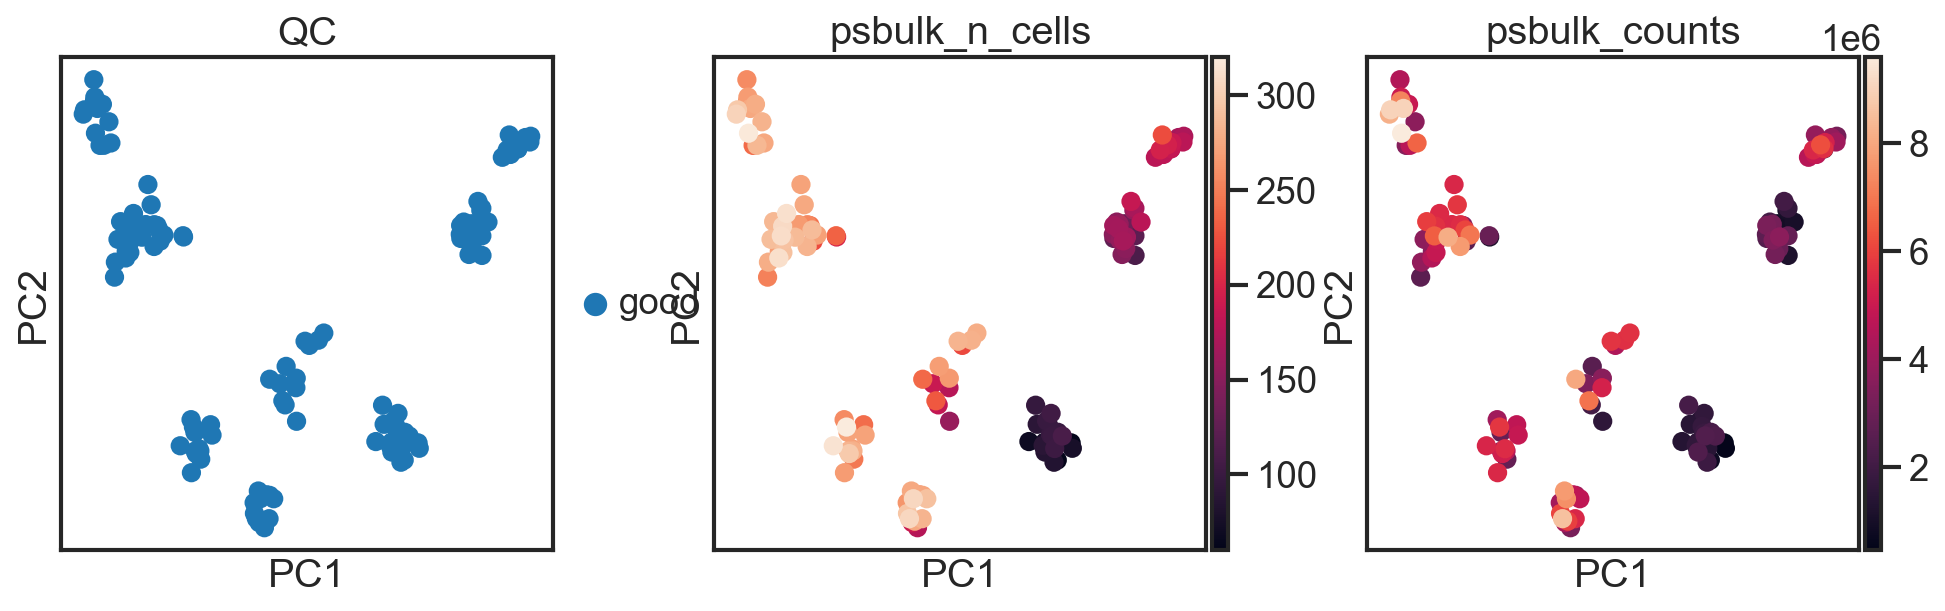

In [29]:
sc.pl.pca(pdata, color=['QC','psbulk_n_cells', 'psbulk_counts'], ncols=3, size=300)


## perform feature (gene) filtering

In [30]:
count_cutoff = 5
total_cutoff = 250

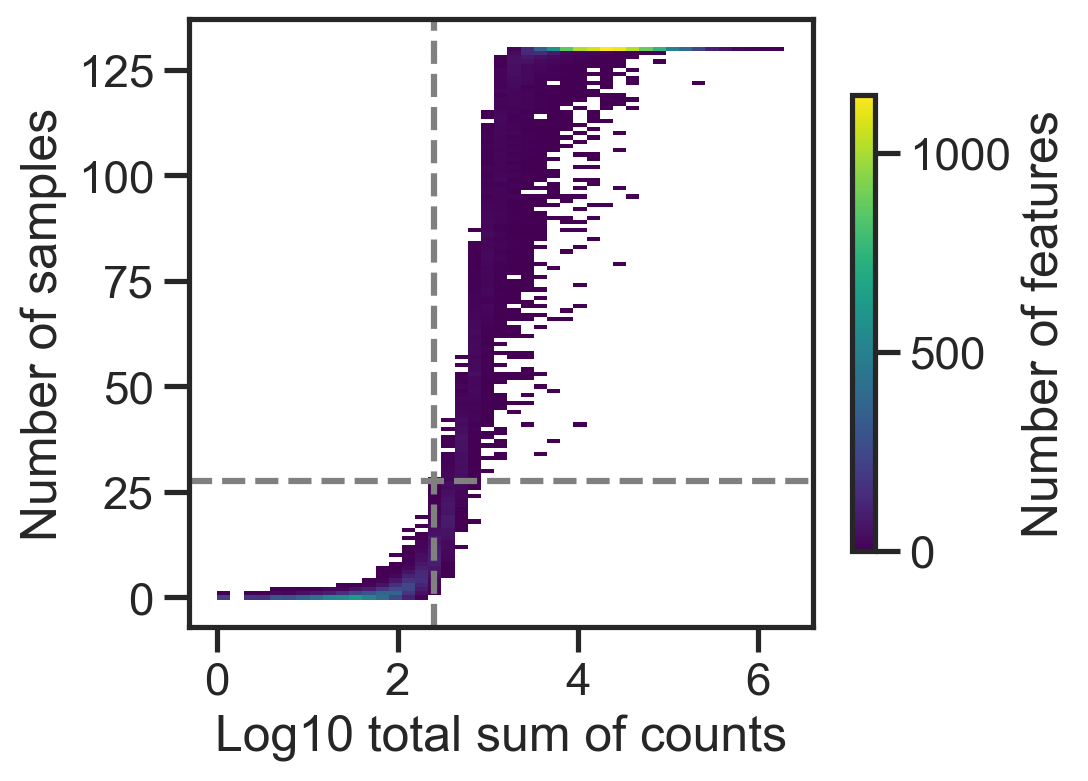

In [31]:
dc.plot_filter_by_expr(pdata, group=groups, min_count=count_cutoff, min_total_count=total_cutoff)
plt.show()

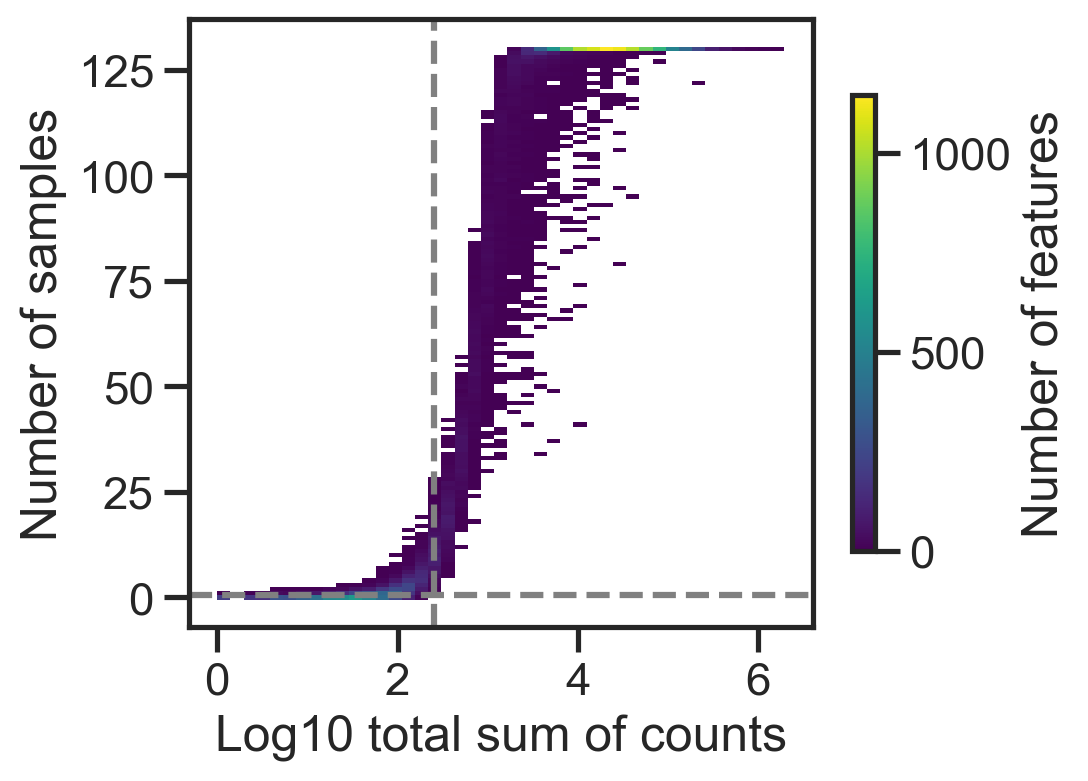

In [32]:
dc.plot_filter_by_expr(pdata, group=reps, min_count=count_cutoff, min_total_count=total_cutoff)
plt.show()

In [33]:
pdata

AnnData object with n_obs × n_vars = 130 × 27268
    obs: 'batch', 'diffx_p_diff', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'QC', 'diffx_ESC_p', 'psbulk_n_cells', 'psbulk_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'pca', 'diffx_p_diff_colors', 'QC_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [34]:
# Obtain genes that pass the thresholds
genes = dc.filter_by_expr(pdata, group=groups, min_count=count_cutoff, min_total_count=total_cutoff)

# Filter by these genes
pdata = pdata[:, genes].copy()
pdata

AnnData object with n_obs × n_vars = 130 × 15575
    obs: 'batch', 'diffx_p_diff', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'QC', 'diffx_ESC_p', 'psbulk_n_cells', 'psbulk_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'pca', 'diffx_p_diff_colors', 'QC_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

## start DEseq differential analysis

In [35]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=1)
dds = DeseqDataSet(
    adata=pdata,
    design=groups,
   # ref_level=list(pdata.obs[groups].unique()),
    refit_cooks=True,
    inference=inference,
)

In [36]:
# Compute LFCs
dds.deseq2()

Fitting size factors...
... done in 0.06 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 8.79 seconds.

Fitting dispersion trend curve...
... done in 0.29 seconds.

Fitting MAP dispersions...
... done in 10.99 seconds.

Fitting LFCs...
... done in 3.46 seconds.

Calculating cook's distance...
... done in 0.11 seconds.

Replacing 2 outlier genes.

Fitting dispersions...
... done in 0.00 seconds.

Fitting MAP dispersions...
... done in 0.00 seconds.

Fitting LFCs...
... done in 0.00 seconds.



In [37]:
list(pdata.obs[groups].unique())

['Pluripotent', 'diff']

In [38]:
pdata.obs[groups] = pdata.obs[groups].cat.reorder_categories(['diff','Pluripotent'])

In [39]:
# Extract contrast between LINS vs ESC
stat_res = DeseqStats(
    dds,
    contrast=[groups] +  list(pdata.obs[groups].cat.categories),
    inference=inference,
)

In [40]:
# Compute Wald test
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: diffx_p_diff diff vs Pluripotent
                 baseMean  log2FoldChange     lfcSE       stat        pvalue  \
Gene                                                                           
0610009B22Rik   34.849370        0.071394  0.082240   0.868117  3.853302e-01   
0610009E02Rik   16.462047       -0.171492  0.086807  -1.975538  4.820714e-02   
0610009L18Rik    7.787461        0.436968  0.126270   3.460574  5.390249e-04   
0610012G03Rik   43.409860        0.085911  0.103990   0.826146  4.087214e-01   
0610030E20Rik   67.665400        0.213386  0.041302   5.166425  2.386144e-07   
...                   ...             ...       ...        ...           ...   
Zyg11b         460.411156        0.318875  0.027782  11.477927  1.703148e-30   
Zyx            229.974498       -0.744586  0.078046  -9.540310  1.424056e-21   
Zzef1          239.860416        0.393766  0.060938   6.461737  1.035080e-10   
Zzz3           721.747706        0.106985  0.0220

... done in 1.03 seconds.



In [41]:
# Extract results
results_df = stat_res.results_df

results_df.head(2)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
0610009B22Rik,34.849370,0.071394,0.082240,0.868117,0.385330,0.431113
0610009E02Rik,16.462047,-0.171492,0.086807,-1.975538,0.048207,0.063063


/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


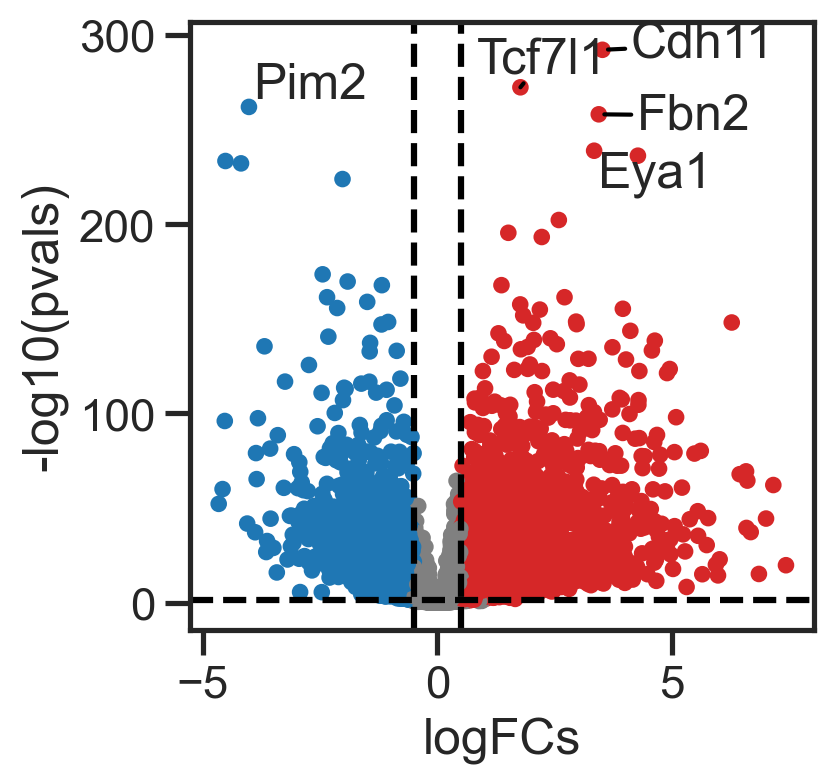

In [42]:

dc.plot_volcano_df(
    results_df,
    x='log2FoldChange',
    y='padj',
    top=5,
    figsize=(4,4)
)
plt.show()

## Identify diff expressed genes

In [43]:
results_df['p_log10'] = -np.log10(results_df['padj'])
#results_df = results_df[np.isfinite(results_df['p_log10'])]


up = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] > 2)].sort_values(by = 'log2FoldChange',ascending=True)

down = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] < -2)].sort_values(by = 'log2FoldChange',ascending=True)


/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [44]:
results_df.head(2)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,p_log10
Gene,,,,,,,
0610009B22Rik,34.849370,0.071394,0.082240,0.868117,0.385330,0.431113,0.365409
0610009E02Rik,16.462047,-0.171492,0.086807,-1.975538,0.048207,0.063063,1.200226


In [45]:
results_df.to_csv('dfs/20250303_diff_genes_PvsDIFF.csv')

In [46]:
up.shape

(705, 7)

In [47]:
down.shape

(150, 7)

In [48]:
pdata

AnnData object with n_obs × n_vars = 130 × 15575
    obs: 'batch', 'diffx_p_diff', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'QC', 'diffx_ESC_p', 'psbulk_n_cells', 'psbulk_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'pca', 'diffx_p_diff_colors', 'QC_colors', 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'X_pca', 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable'
    varm: 'PCs', '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    layers: 'psbulk_props', 'counts', 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks'

# do standard scanpy diff gene analysis

In [49]:
sc.tl.rank_genes_groups(adata_f, groupby = groups,method='wilcoxon')

ranking genes


/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:645: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


    finished (0:01:11)


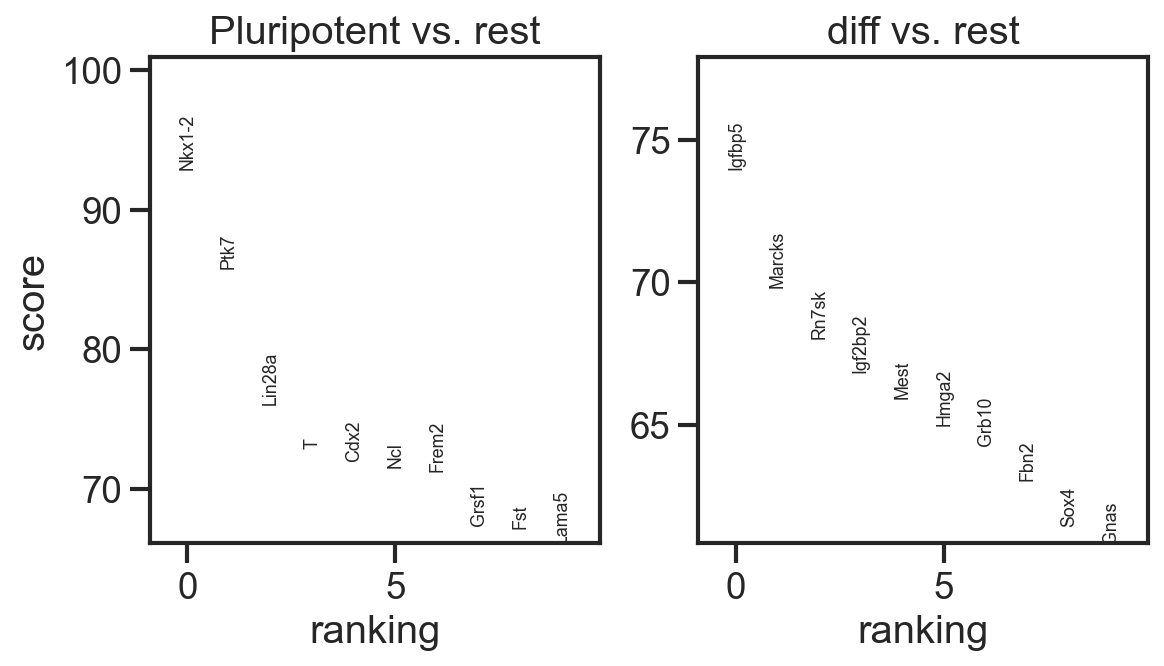

In [50]:
sc.pl.rank_genes_groups(adata_f, n_genes=10, sharey=False)


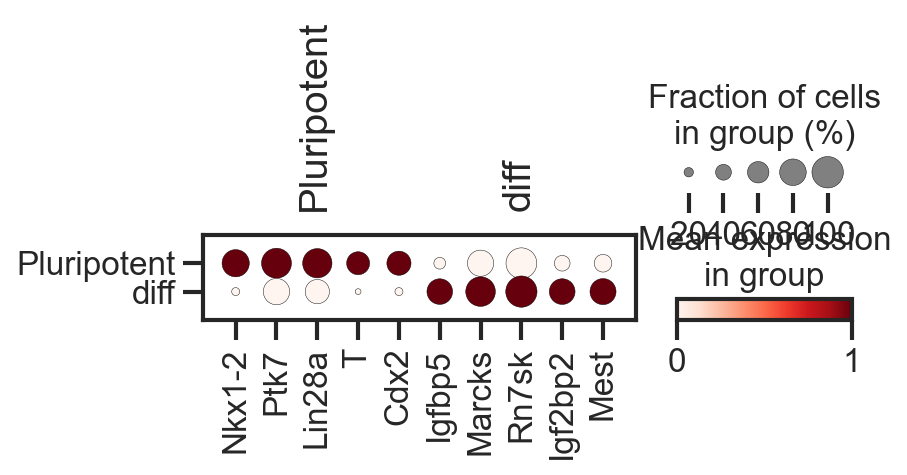

In [51]:
sc.pl.rank_genes_groups_dotplot(
    adata_f, groupby=groups, standard_scale="var", n_genes=5
)
plt.show()

In [75]:
diff_exp = sc.get.rank_genes_groups_df(adata_f, group=list(pdata.obs[groups].unique())[0])
diff_exp.index = diff_exp['names']
diff_exp = diff_exp.rename(columns = {'logfoldchanges':'log2FoldChange', 'pvals_adj': 'padj','scores':'stat'})
diff_exp['p_log10'] = -np.log10(diff_exp['padj'])
#diff_exp = diff_exp[np.isfinite(diff_exp['p_log10'])]

diff_exp['log2FoldChange'] = -diff_exp['log2FoldChange']
scanpy_up = diff_exp[(diff_exp['log2FoldChange'] > 2) & (diff_exp['padj'] < 0.05)]
scanpy_down = diff_exp[(diff_exp['log2FoldChange'] < -2) & (diff_exp['padj'] < 0.05)]


/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


In [76]:
scanpy_up.shape

(512, 6)

In [100]:
scanpy_down

,names,stat,log2FoldChange,pvals,padj,p_log10
names,,,,,,
Nkx1-2,Nkx1-2,92.906540,-3.778379,0.000000,0.000000,inf
T,T,72.896935,-3.915816,0.000000,0.000000,inf
Cdx2,Cdx2,72.003212,-2.885579,0.000000,0.000000,inf
Frem2,Frem2,71.269249,-2.071665,0.000000,0.000000,inf
Fst,Fst,67.159187,-3.115426,0.000000,0.000000,inf
...,...,...,...,...,...,...
Gbp2,Gbp2,2.791382,-3.109252,0.005248,0.028510,1.545004
Hs3st4,Hs3st4,2.735683,-2.428769,0.006225,0.033491,1.475071
Gm11549,Gm11549,2.727980,-2.353205,0.006372,0.034233,1.465560


In [77]:
scanpy_down.shape

(171, 6)

# check intersect between deseq2 and scanpy

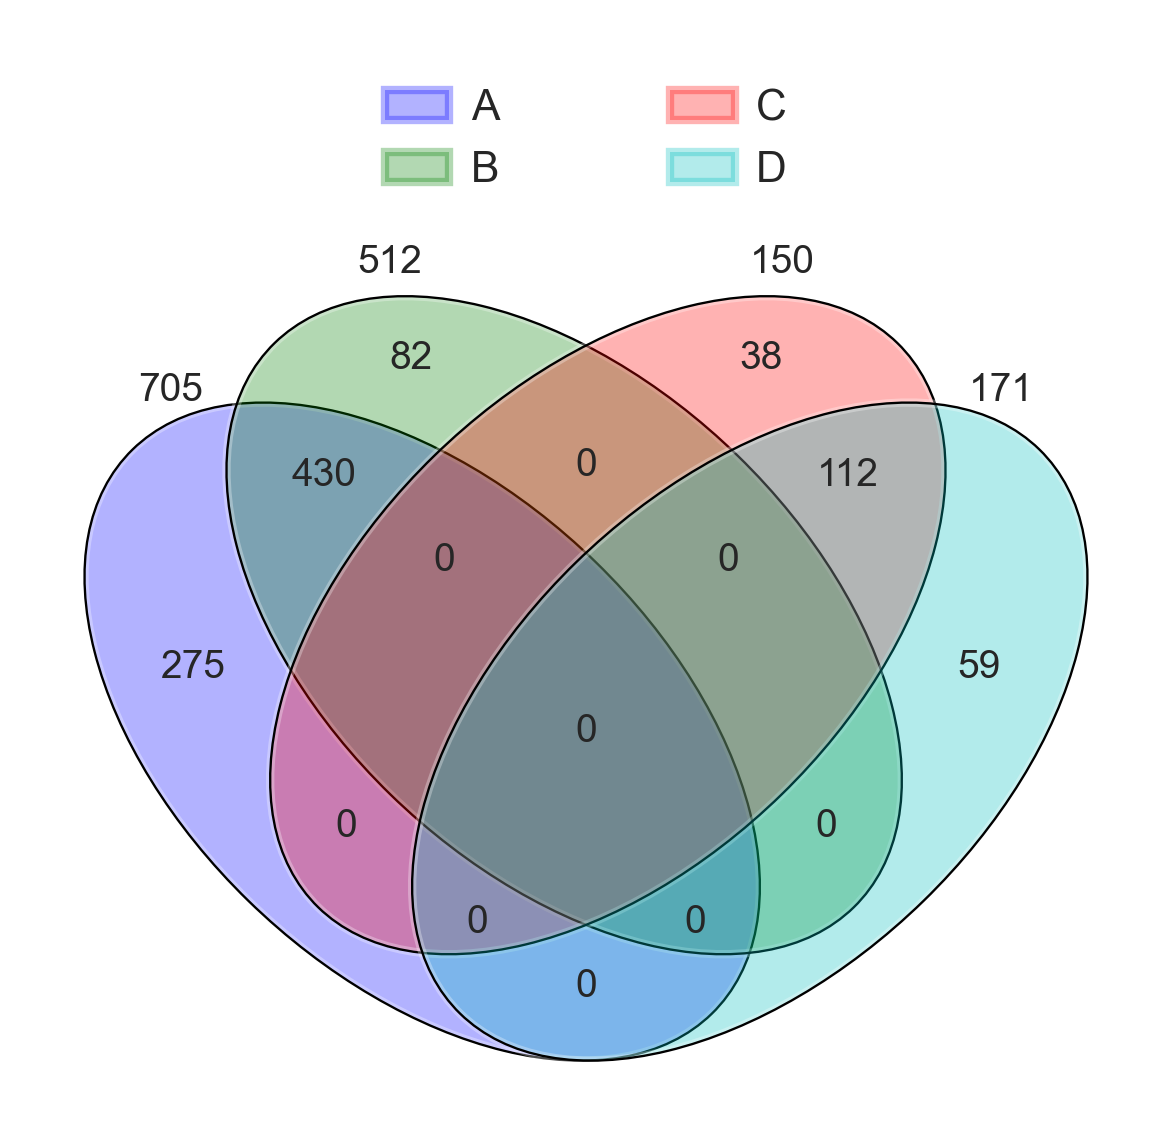

In [78]:
from venny4py.venny4py import *

#dict of sets
sets = {
    'A': set(list(up.index)),
    'B': set(list(scanpy_up['names'])),
    'C': set(list(down.index)),
    'D': set(list(scanpy_down['names']))}
    
venny4py(sets=sets, )#colors = list(lin_colors.values()),)

#plt.savefig('figs/venn4.png',bbox_inches='tight')
plt.show()

In [79]:
sc.set_figure_params(dpi = 80)

sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

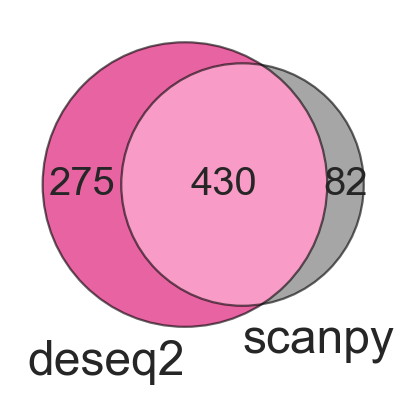

In [101]:
from matplotlib_venn import venn2, venn2_circles

A = up.index
B = scanpy_up['names']

fig,ax = plt.subplots(figsize = (3,3))
venn2([set(A),set(B)],ax=ax, set_colors = [adata.uns[str(groups) + '_colors'][1] , 'grey'],set_labels = ['deseq2','scanpy'],
      alpha = 0.7)
c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

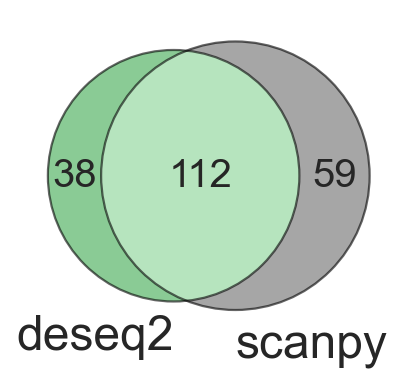

In [102]:
from matplotlib_venn import venn2, venn2_circles

A = down.index
B = scanpy_down['names']

fig,ax = plt.subplots(figsize = (3,3))
venn2([set(A),set(B)],ax=ax, set_colors = [adata.uns[str(groups) + '_colors'][0] , 'grey'], set_labels = ['deseq2','scanpy'],
      alpha = 0.7)
c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)
#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

# all plots for diff expressed genes

In [103]:
def makeVolcano(df, df_up, df_down, lfc = 'log2FoldChange'):
    fig,ax = plt.subplots(figsize = (4,4))
    
    sns.scatterplot(data = df,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',alpha = 0.4,
                   c = 'grey')
    
    sns.scatterplot(data = df_up,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',
                   c = adata.uns[str(groups) + '_colors'][1] )
    
    sns.scatterplot(data = df_down,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',
                   c = adata.uns[str(groups) + '_colors'][0] )
    ax.legend([],frameon=False)
    ax.set_ylabel('log10 [p-value]')
    ax.set_xlabel('log2 FC')
    
    
    #plt.savefig('figs/volcanoes_diffexpressed.png', bbox_inches='tight')
    plt.show()

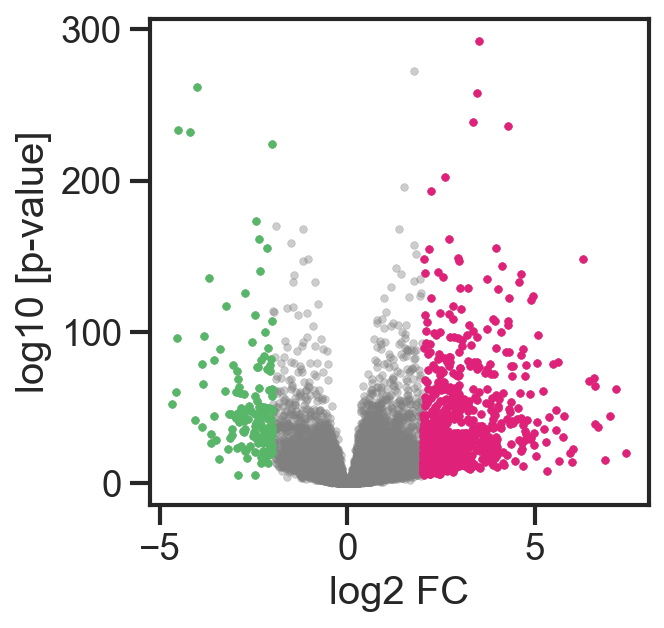

In [104]:
makeVolcano(results_df,up,down)

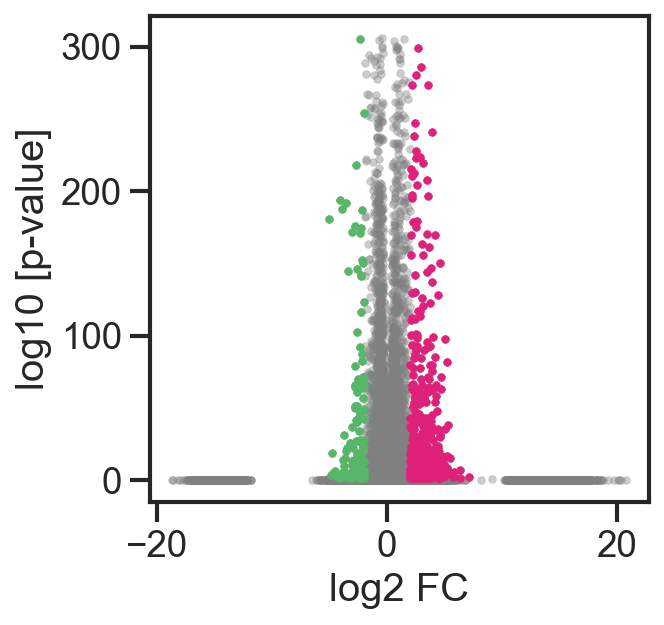

In [105]:
makeVolcano(diff_exp,scanpy_up,scanpy_down)

In [85]:
allgenes = list(results_df.index.unique())
def plotGO(genelist, reflist, n = 10, save = None, source = 'GO:BP'):
    plotcl = sc.queries.enrich({'cluster':genelist,
                   'all':reflist}, org="mmusculus")
    cluster = 'cluster'
    plot1 = plotcl[plotcl['query'] == cluster][plotcl[plotcl['query'] == cluster]['source'] == source].sort_values(by='p_value')[['name','p_value']][0:n]
    plot1['-log (p-value)'] = np.log10(plot1['p_value'])*-1
    sns.set_style('ticks')
    sns.set_context('talk')
    fig,ax = plt.subplots(figsize = (6,3))
    ax = sns.barplot(y=plot1['name'],x=plot1['-log (p-value)'], ax=ax,color = 'grey')
    ax.set_ylabel('')
    if save != None:
        plt.savefig(save , bbox_inches='tight')
    #sns.despine()
    plt.show()

In [86]:
len(list(up.index))

705

In [87]:
len(list(down.index))

150

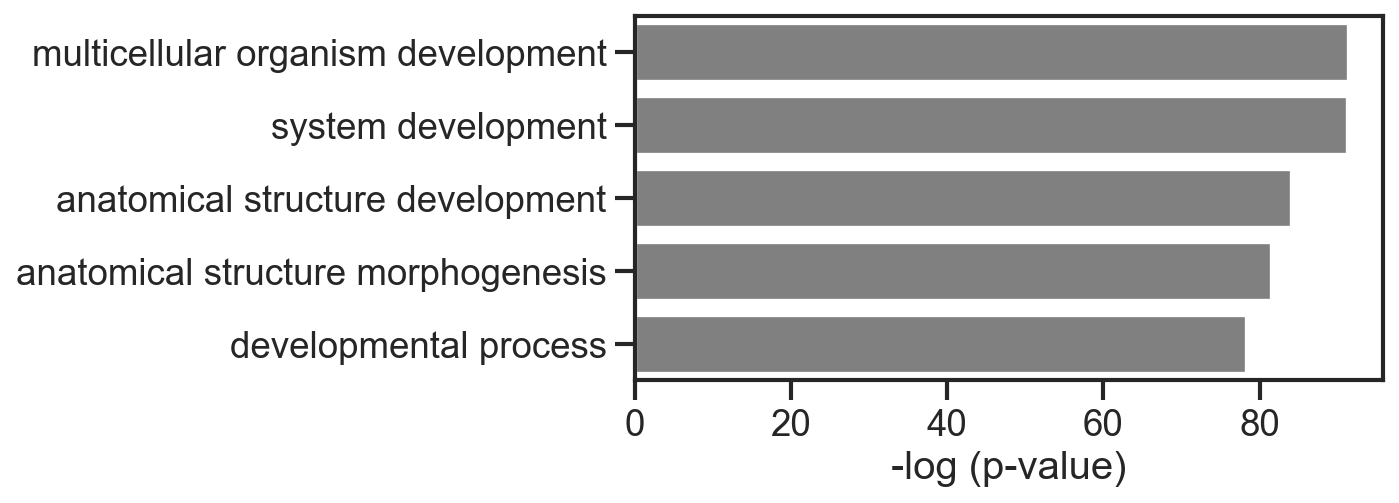

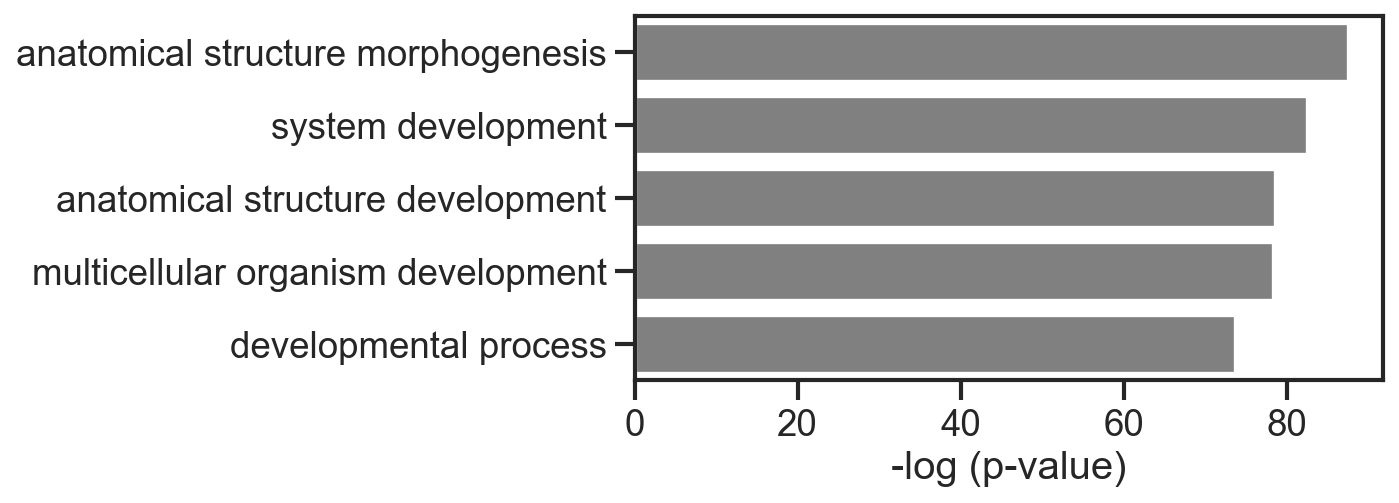

In [88]:
plotGO(list(up.index),allgenes, n = 5)
plotGO(list(scanpy_up['names']),allgenes, n = 5)

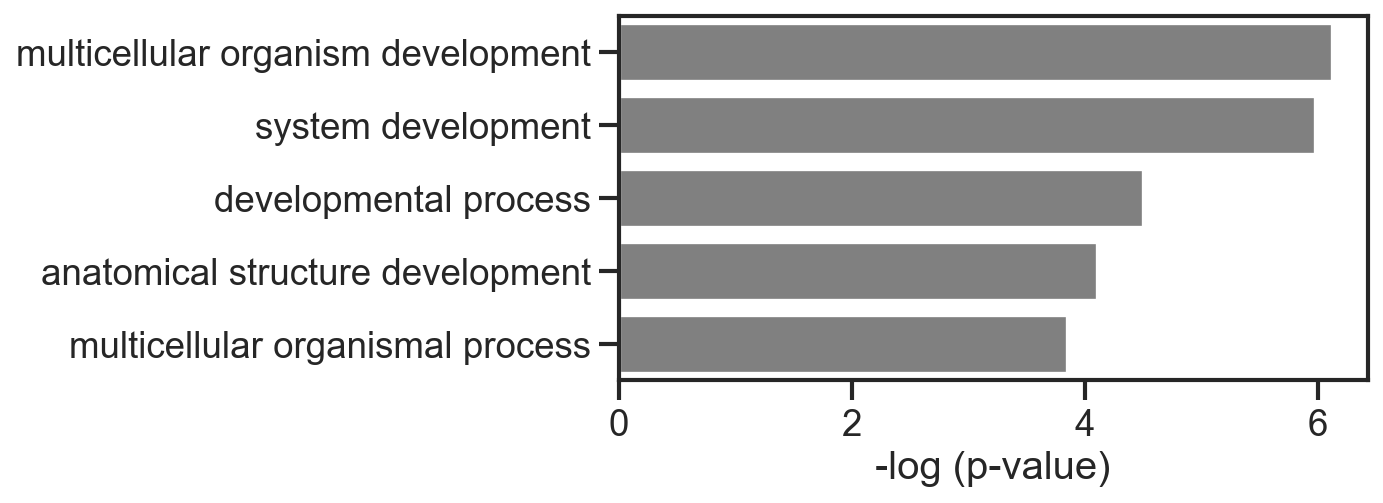

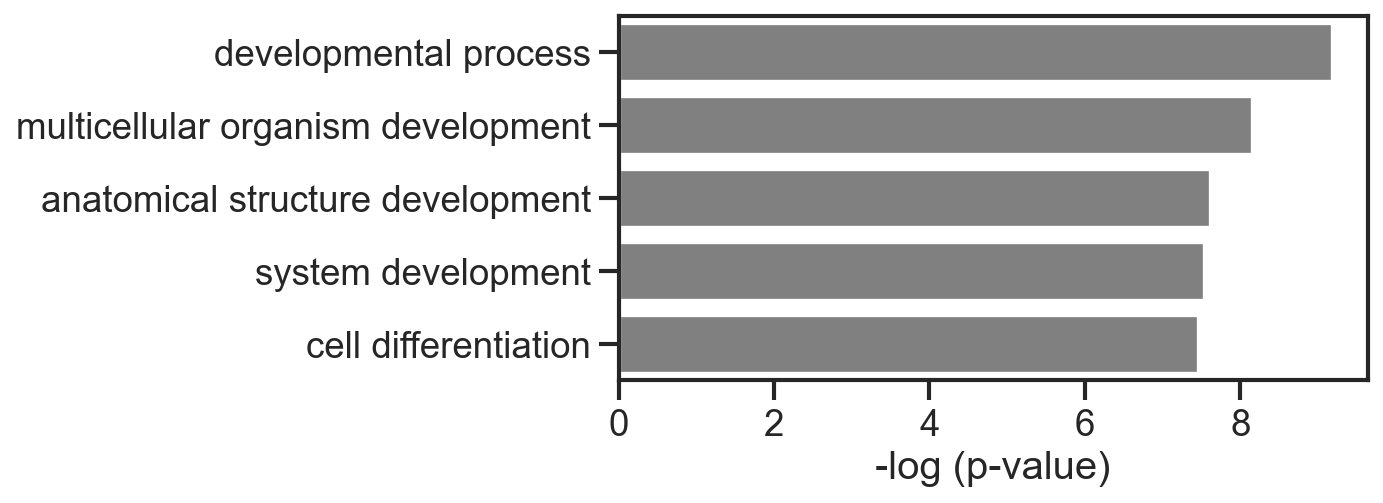

In [89]:
plotGO(list(down.index),allgenes, n = 5)
plotGO(list(scanpy_down['names']),allgenes, n = 5)

## Gene regulatory network analysis

In [90]:
# Retrieve CollecTRI gene regulatory network
collectri = dc.get_collectri(organism='mouse', split_complexes=False,)

collectri.head(2)

/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/liana/resource/_orthology.py:199: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,source,target,weight
0,AP1,Aanat,1
1,AP1,Abca1,-1


In [91]:
def plotTFs(df, save = None):
    mat = df[['stat']].T.rename(index={'stat': 'diff'})
    tf_acts, tf_pvals = dc.run_ulm(mat=mat, net=collectri)
    dc.plot_barplot(
    acts=tf_acts,
    contrast='diff',
    top=25,
    vertical=True,
    figsize=(3, 6)
    )
    if save != None:
        plt.savefig(save, bbox_inches = 'tight')
    plt.show()

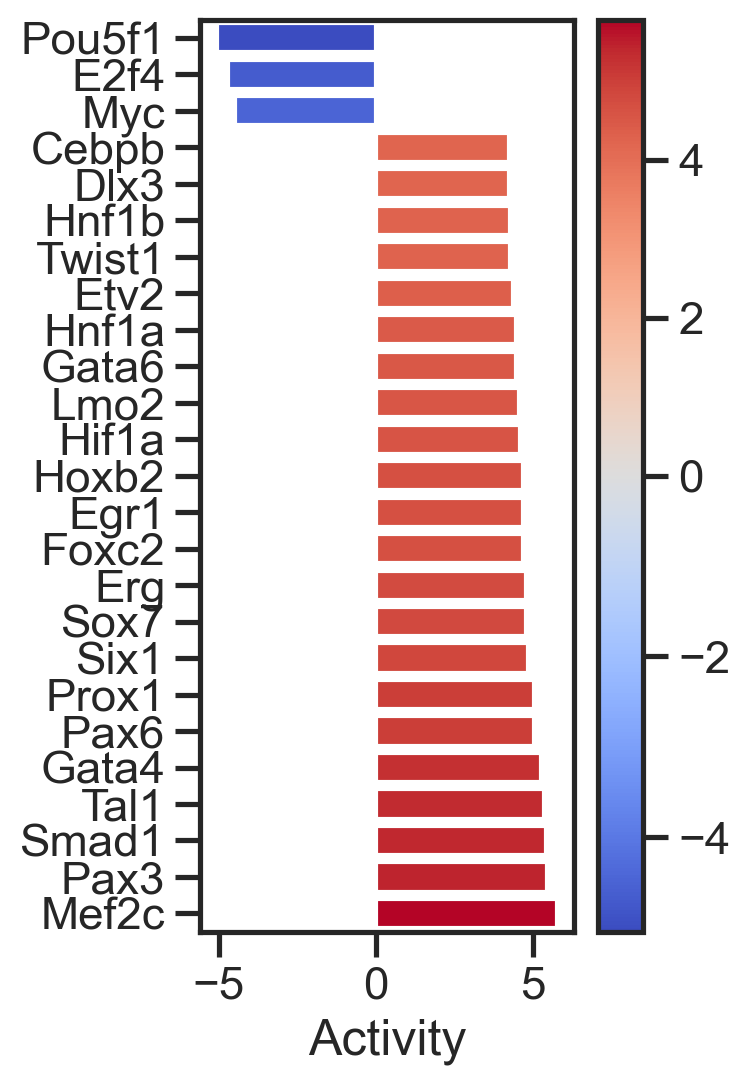

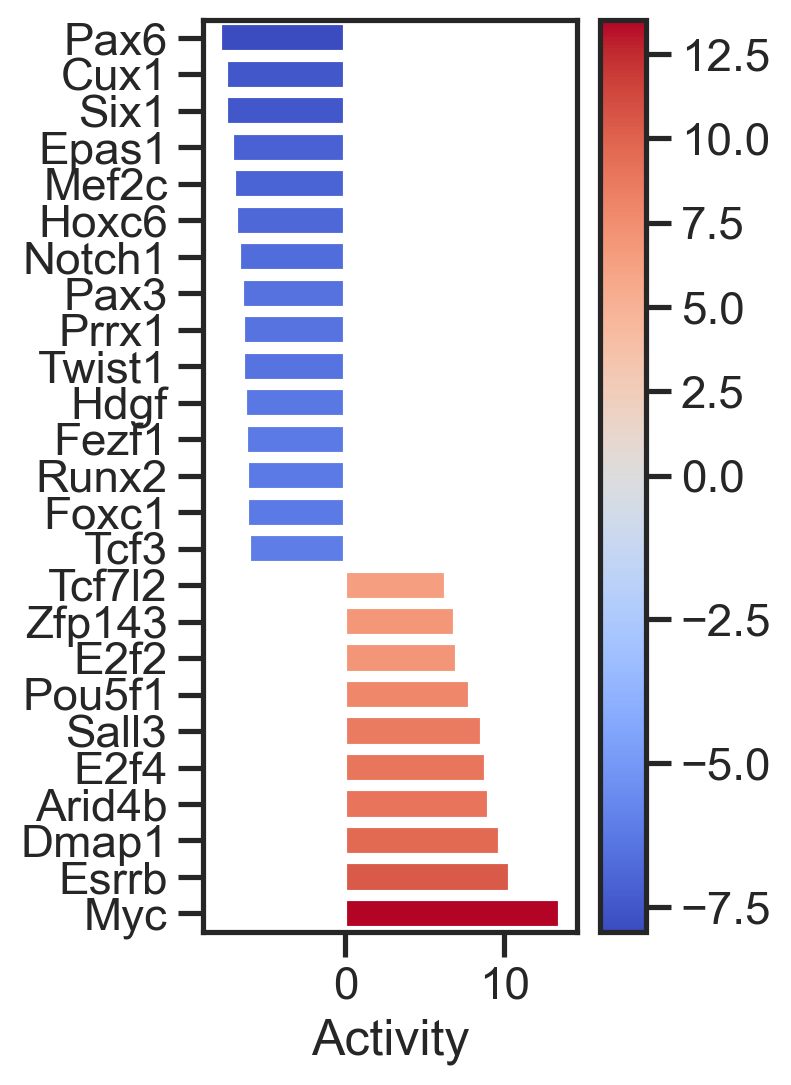

In [92]:
plotTFs(results_df)
plotTFs(diff_exp)

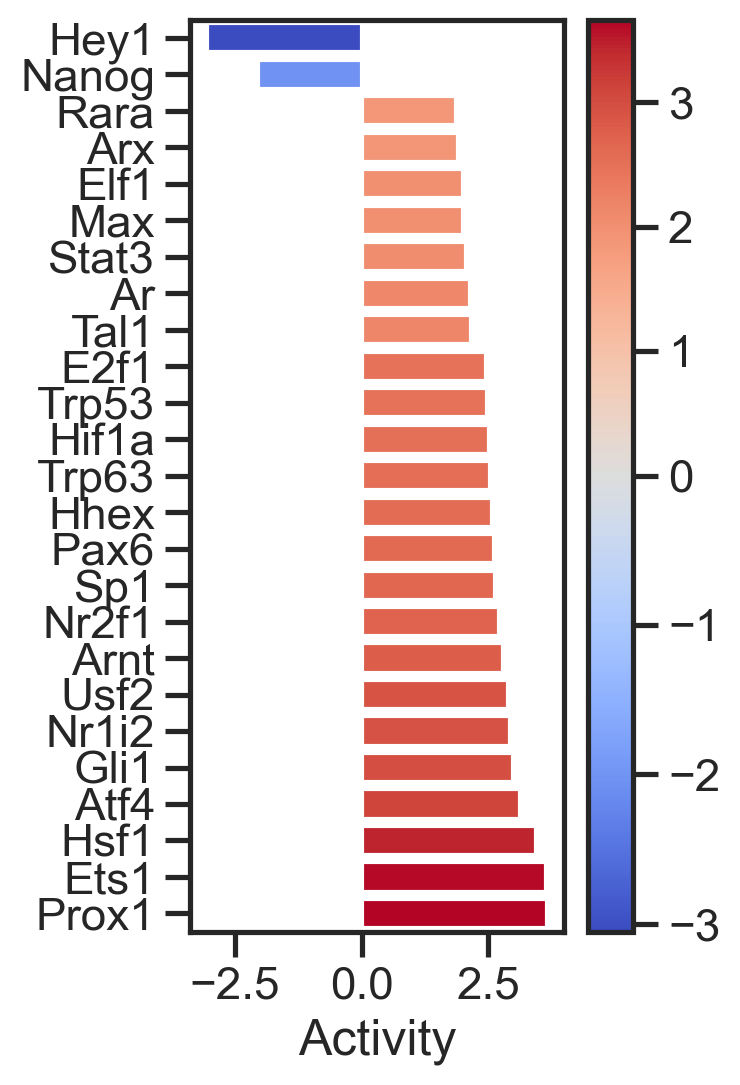

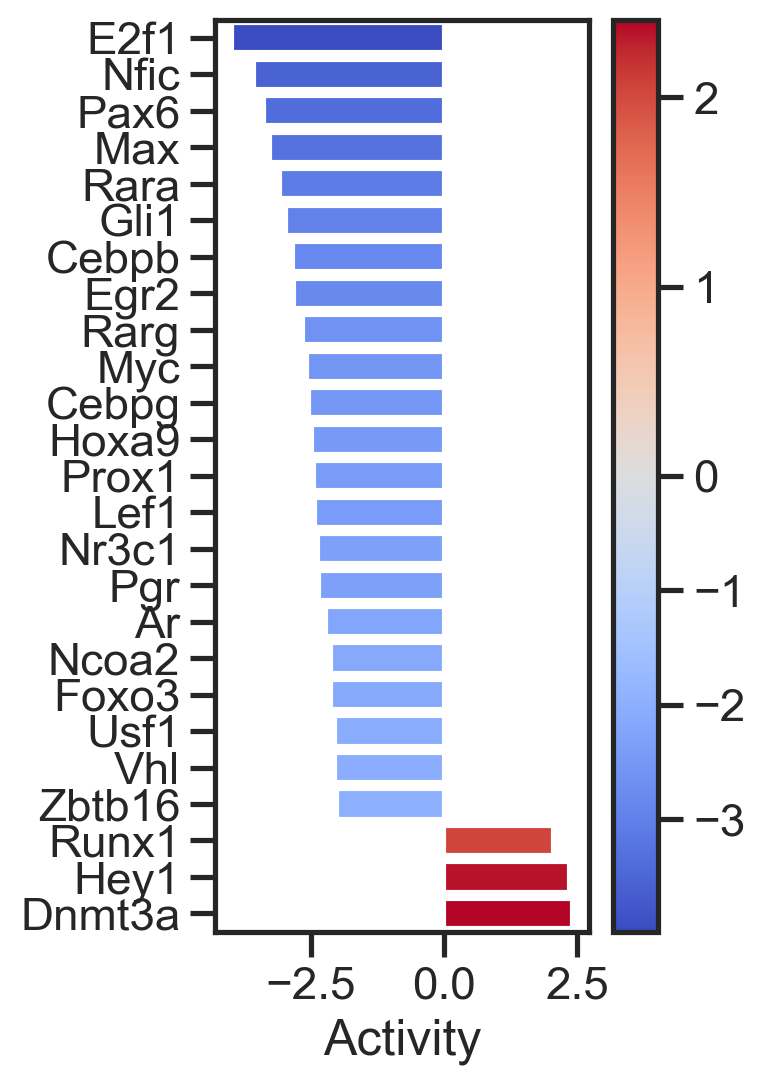

In [93]:
plotTFs(up)
plotTFs(scanpy_up)

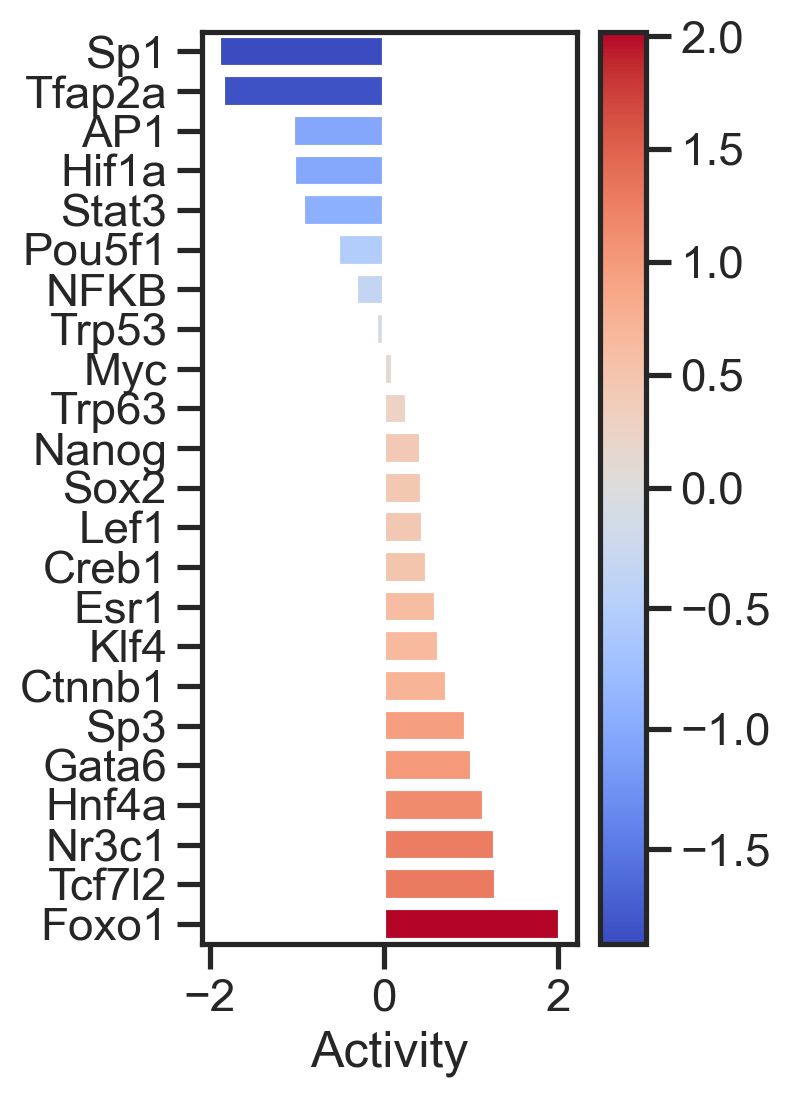

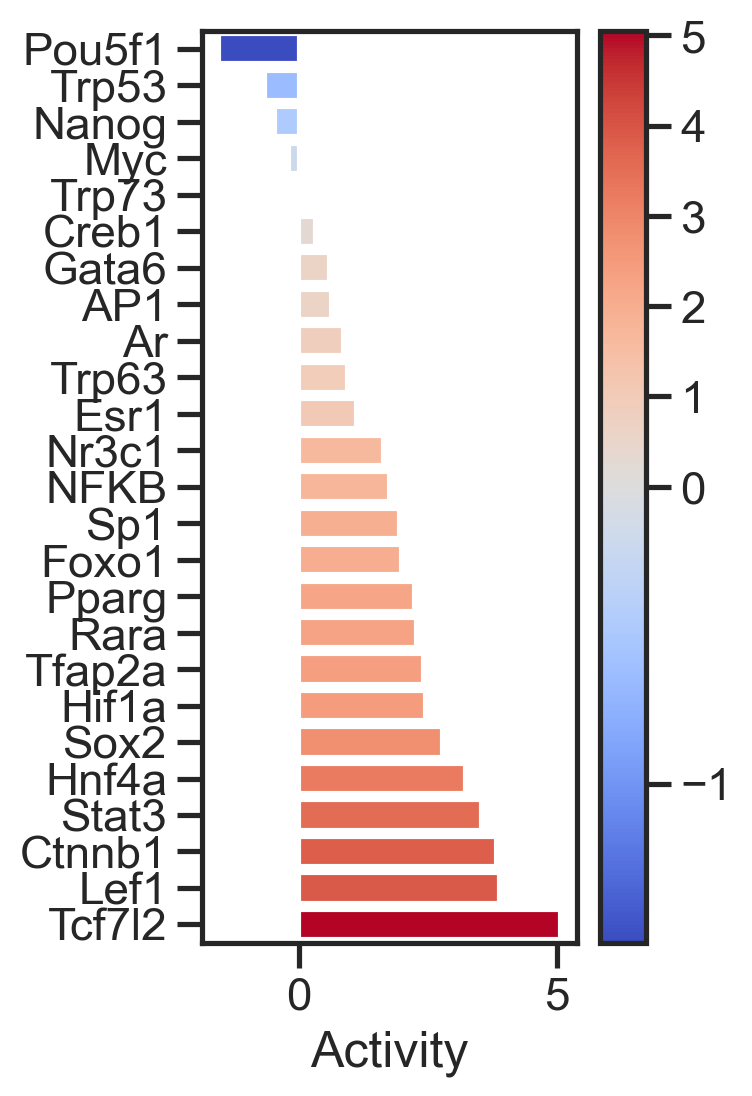

In [94]:
plotTFs(down)
plotTFs(scanpy_down)

### check overlaps

In [95]:
overlap_full = set(results_df.index) & set(diff_exp.index)
overlap_up = set(up.index) & set(scanpy_up.index)
overlap_down = set(down.index) & set(scanpy_down.index)


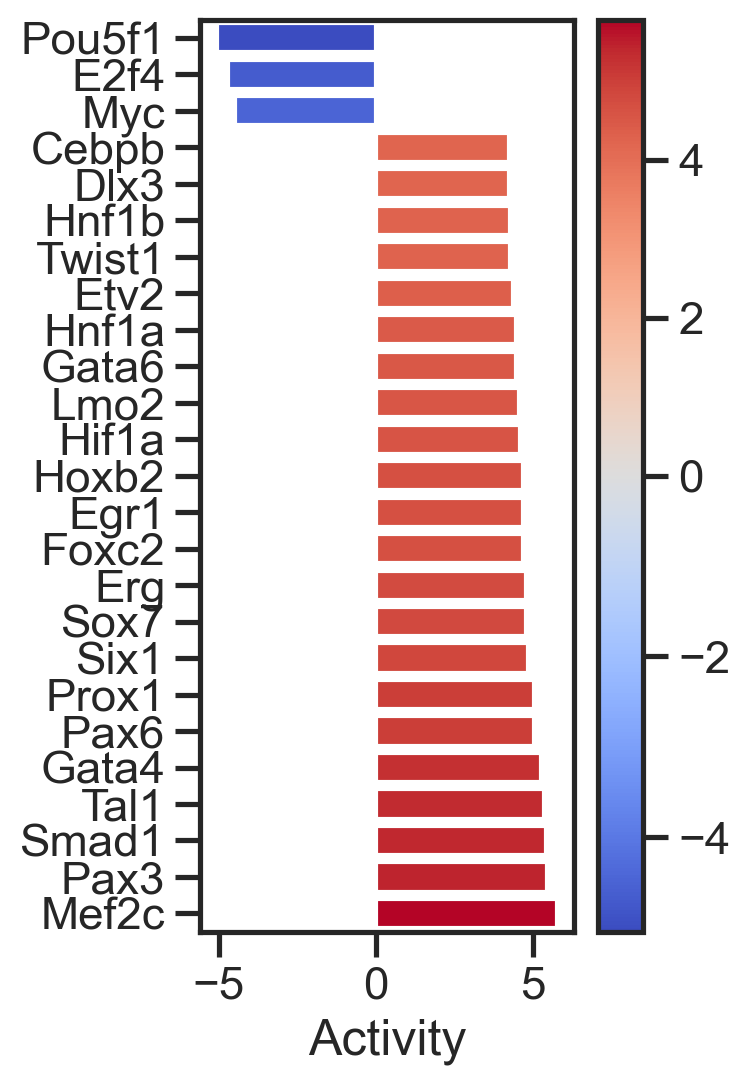

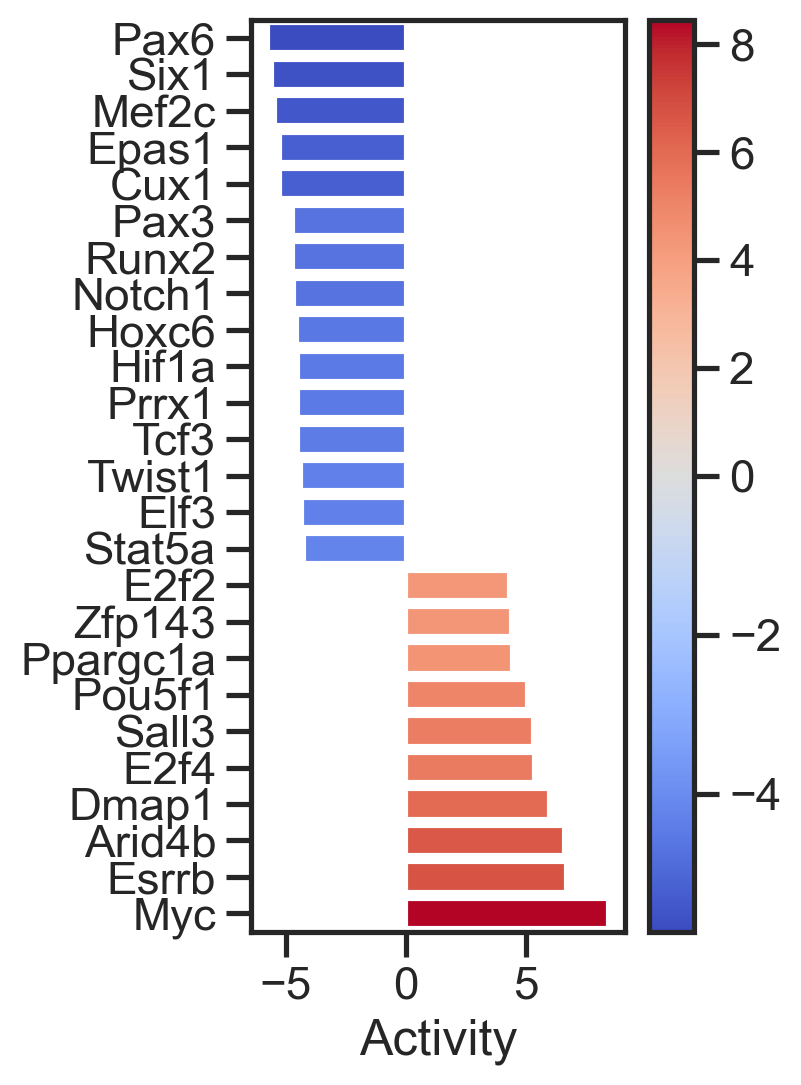

In [96]:
plotTFs(results_df.loc[list(overlap_full)])
plotTFs(diff_exp.loc[list(overlap_full)])

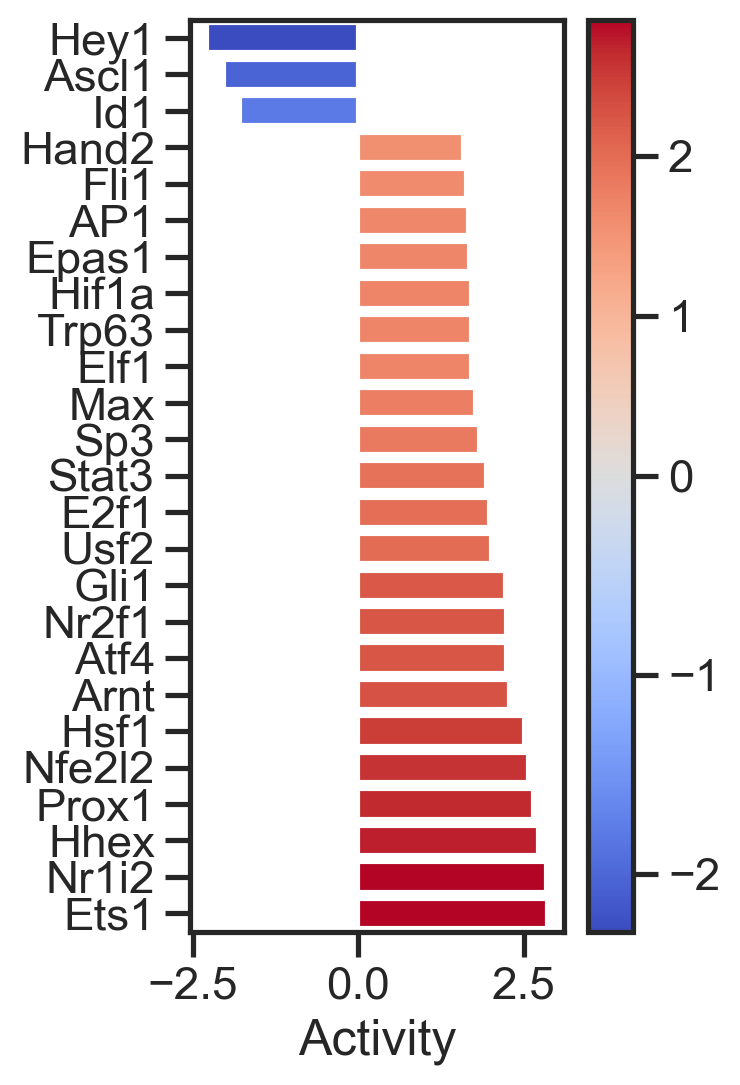

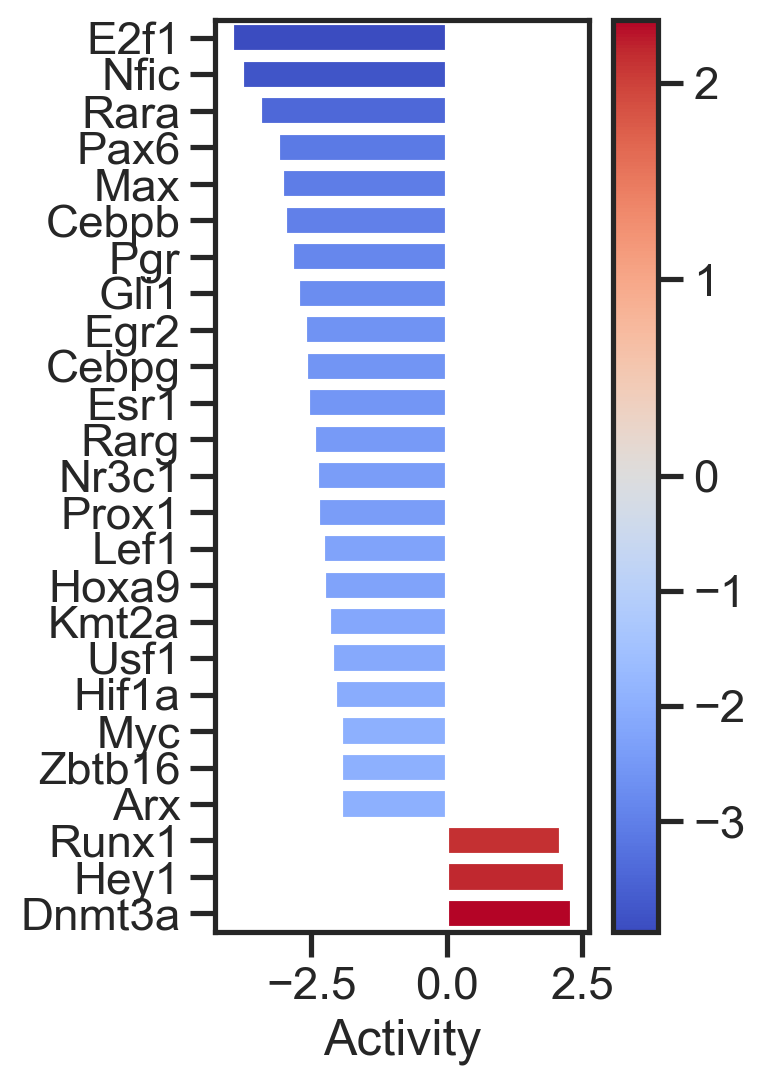

In [97]:
plotTFs(up.loc[list(overlap_up)])
plotTFs(scanpy_up.loc[list(overlap_up)])

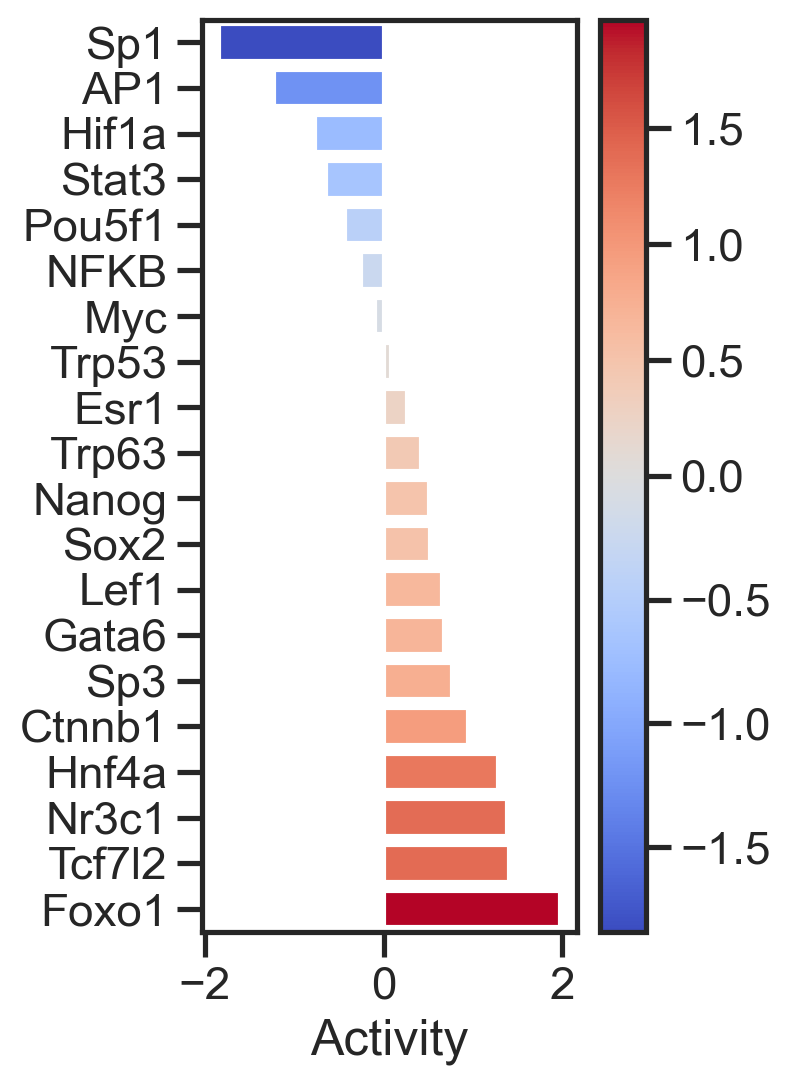

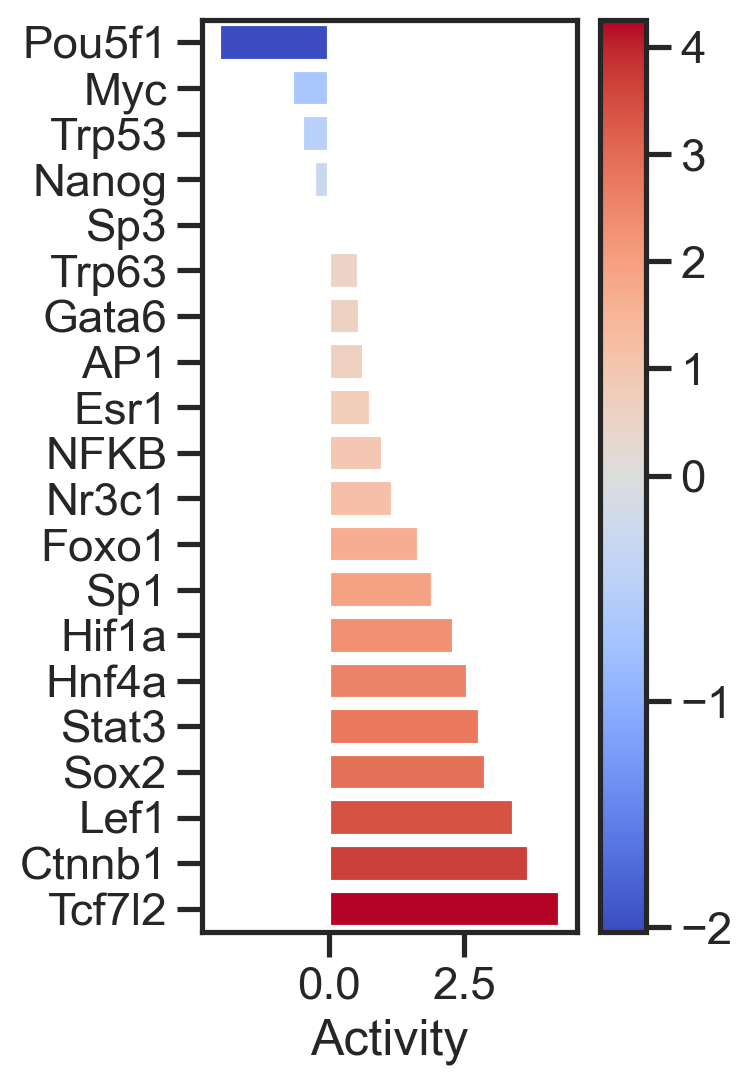

In [98]:
plotTFs(down.loc[list(overlap_down)])
plotTFs(scanpy_down.loc[list(overlap_down)])

## conclusions: deseq and scanpy do largely agree on the genes that are differentially expressed, but the scores are wildly different. Therefore, the venn diagram shows considerable overlap between the gene sets and the (geneset-based) GO analysis is also comparable, but the (score-based) TF activity inference shows different results.